# Energy & Oil Market Analysis (2017–2022)

This notebook analyzes the US Energy sector using 10 ETFs and the underlying physical crude benchmarks and DOE inventories.

**Data sources**
| Folder | File | Description |
|---|---|---|
| `data/energy/` | `FENY.csv`, `IXC.csv`, `IYE.csv`, `OIH.csv`, `PXE.csv`, `RYE.csv`, `VDE.csv`, `XES.csv`, `XLE.csv`, `XOP.csv` | yfinance daily OHLCV for ten energy-sector ETFs |
| `data/oil/` | `WTI_cushing_crude_oil_SPOT.csv` | WTI Cushing spot price ($/bbl) |
| `data/oil/` | `WTI_midland_index.csv` | WTI Midland index ($/bbl) |
| `data/oil/` | `BIDY.csv` | Bidirectional yield/proxy series |
| `data/oil/` | `crude_oil_futures_price_and_inventory.xlsx` | NYMEX WTI futures (price, OI, volume) + DOE crude inventory + weekly inventory change |

ETF Energy tickers:
* **FENY** (Fidelity Energy)
* **IXC** (iShares Global Energy)
* **IYE** (iShares US Energy)
* **OIH** (VanEck Oil Services)
* **PXE** (Invesco Energy Exploration & Production)
* **RYE** (Invesco S&P 500 Equal Weight Energy)
* **VDE** (Vanguard Energy)
* **XES** (SPDR S&P Oil & Gas Equipment & Services)
* **XLE** (Energy Select Sector SPDR)
* **XOP** (SPDR S&P Oil & Gas E&P)


**Analysis Sections**

1. Price history of the four core series
2. WTI Cushing vs Midland spread
3. Daily-return distributions and rolling volatility
4. Correlation matrix and rolling FENY–WTI correlation
5. DOE inventory vs futures price
6. Futures market microstructure (open interest, volume)
7. Rolling beta of FENY vs WTI
8. Drawdown from all-time high
9. Monthly-return seasonality
10. 50/200-day moving-average crosses
11. Annual returns by asset
12. FENY volume + on-balance volume
13. Summary statistics table
14. Normalized performance across all ten energy ETFs
15. Full ETF correlation heatmap
16. ETF risk-return scatter with Sharpe ranking

## Setup analysis

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats

In [2]:
# Data folders
DATA      = "data"
ENERGY    = os.path.join(DATA, "energy") # ETF csv's from yfinance
OIL       = os.path.join(DATA, "oil") # WTI, BIDY, futures and inventory
OUT       = "outputs"
os.makedirs(OUT, exist_ok=True)

# Energy ETFs
ETFS = ["FENY", "IXC", "IYE", "OIH", "PXE", "RYE", "VDE", "XES", "XLE", "XOP"]

# Time frame
START, END = "2017-01-01", "2022-12-31"

In [3]:
C = dict(
    feny = "#2196F3", # blue
    bidy = "#FF9800", # amber
    wti_c = "#4CAF50", # green - WTI Cushing
    wti_m = "#9C27B0", # purple - WTI Midland
    fut = "#F44336", # red - futures
    inv = "#607D8B", # slate - inventory
    bg = "#0D1117",
    panel = "#161B22",
    grid = "#21262D",
    text = "#E6EDF3",
    muted = "#8B949E",
    accent = "#F0B429",
)

plt.rcParams.update({
    "figure.facecolor": C["bg"],
    "axes.facecolor": C["panel"],
    "axes.edgecolor": C["grid"],
    "axes.labelcolor": C["text"],
    "axes.titlecolor": C["text"],
    "xtick.color": C["muted"],
    "ytick.color": C["muted"],
    "grid.color": C["grid"],
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "text.color": C["text"],
    "legend.facecolor": C["panel"],
    "legend.edgecolor": C["grid"],
    "font.family": "monospace",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save(fig, name):
    # Save graphs with dark background
    path = os.path.join(OUT, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=C["bg"])
    print(f"  saved -> {path}")

## 0. Load data

In [4]:
def load_oil_csv(path, price_col="Last Price"):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    return df

def load_etf_csv(path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Close"]  = pd.to_numeric(df["Close"], errors="coerce")
    df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")
    return df

In [5]:
# Oil data
bidy  = load_oil_csv(os.path.join(OIL, "BIDY.csv")).rename(columns={"Last Price": "bidy"})
wti_c = load_oil_csv(os.path.join(OIL, "WTI_cushing_crude_oil_SPOT.csv")).rename(columns={"Last Price": "wti_cushing"})
wti_m = load_oil_csv(os.path.join(OIL, "WTI_midland_index.csv")).rename(columns={"Last Price": "wti_midland"})

xl = pd.ExcelFile(os.path.join(OIL, "crude_oil_futures_price_and_inventory.xlsx"))
fut = xl.parse("Crude Oil Futures Price ").rename(columns={"Last Price": "fut_price", "Open Interest": "open_int", "Volume": "fut_vol"})
inv = xl.parse("DOE Crude Oil Inventory").rename(columns={"Last Price": "inventory"})
inv_ch = xl.parse("DOE Inventory Change").rename(columns={"Last Price": "inv_change"})

for d in (fut, inv, inv_ch):
    d["Date"] = pd.to_datetime(d["Date"])
    d.sort_values("Date", inplace=True)

print(f"bidy {bidy['Date'].min().date()} -> {bidy['Date'].max().date()}  ({len(bidy):,})")
print(f"wti_c {wti_c['Date'].min().date()} -> {wti_c['Date'].max().date()}  ({len(wti_c):,})")
print(f"wti_m {wti_m['Date'].min().date()} -> {wti_m['Date'].max().date()}  ({len(wti_m):,})")
print(f"futures {fut['Date'].min().date()} -> {fut['Date'].max().date()}  ({len(fut):,})")

bidy 2017-01-03 -> 2022-12-23  (1,497)
wti_c 2017-01-03 -> 2022-12-31  (1,507)
wti_m 2017-01-03 -> 2022-12-30  (1,500)
futures 2016-12-09 -> 2022-12-30  (1,534)


In [ ]:
# Energy ETF data
etf_close  = {}
etf_volume = {}
for t in ETFS:
    p = os.path.join(ENERGY, f"{t}_2017-01-01_2023-01-01_1d.csv")
    df = load_etf_csv(p)
    df.set_index("Date", inplace=True)
    etf_close[t]  = df["Close"]
    etf_volume[t] = df["Volume"]

etf_px  = pd.DataFrame(etf_close).sort_index()
etf_vol = pd.DataFrame(etf_volume).sort_index()

# Filter for time frame, fill in nan holiday values
etf_window = etf_px.loc[START:END].dropna(how="all").ffill().bfill()

etf_colors = {t: plt.cm.tab10(i % 10) for i, t in enumerate(ETFS)}

print(f"  ETF price frame: {etf_window.shape}  ({etf_window.index.min().date()} -> {etf_window.index.max().date()})")
print(f"  Tickers: {list(etf_window.columns)}")

  ETF price frame: (1510, 10)  (2017-01-03 -> 2022-12-30)
  Tickers: ['FENY', 'IXC', 'IYE', 'OIH', 'PXE', 'RYE', 'VDE', 'XES', 'XLE', 'XOP']


In [9]:
feny_long = etf_px[["FENY"]].rename(columns={"FENY": "feny"}).reset_index()
feny_long["Volume"] = etf_vol["FENY"].values

master = (feny_long
          .merge(bidy[["Date", "bidy"]], on="Date", how="outer")
          .merge(wti_c[["Date", "wti_cushing"]], on="Date", how="outer")
          .merge(wti_m[["Date", "wti_midland"]], on="Date", how="outer")
          .merge(fut[["Date", "fut_price", "open_int", "fut_vol"]], on="Date", how="outer")
          .sort_values("Date").reset_index(drop=True)
          .set_index("Date"))

master = master.loc[START:END]

# Weekly DOE inventory series, NOTE: this is separate because it is weekly not daily data
inv_w    = inv.set_index("Date")["inventory"]
inv_ch_w = inv_ch.set_index("Date")["inv_change"]

print(f"master frame: {master.shape}")
print(f"date range: {master.index.min().date()} -> {master.index.max().date()}")
master.head()

master frame: (1549, 8)
date range: 2017-01-03 -> 2022-12-31


,feny,Volume,bidy,wti_cushing,wti_midland,fut_price,open_int,fut_vol
Date,,,,,,,,
2017-01-03,15.098448,784800.0,1088.0,52.33,53.43,52.33,454577.0,727793.0
2017-01-04,15.091412,240000.0,1053.0,53.26,54.26,53.26,451079.0,512641.0
2017-01-05,15.035127,235300.0,1024.0,53.76,54.66,53.76,441948.0,517362.0
2017-01-06,15.049198,149100.0,1026.0,53.99,54.73,53.99,417847.0,528333.0
2017-01-09,14.802951,303400.0,1013.0,51.96,52.68,51.96,377643.0,564893.0


## 1. Price history (2017 - 2022)

  saved -> outputs\01_price_history.png


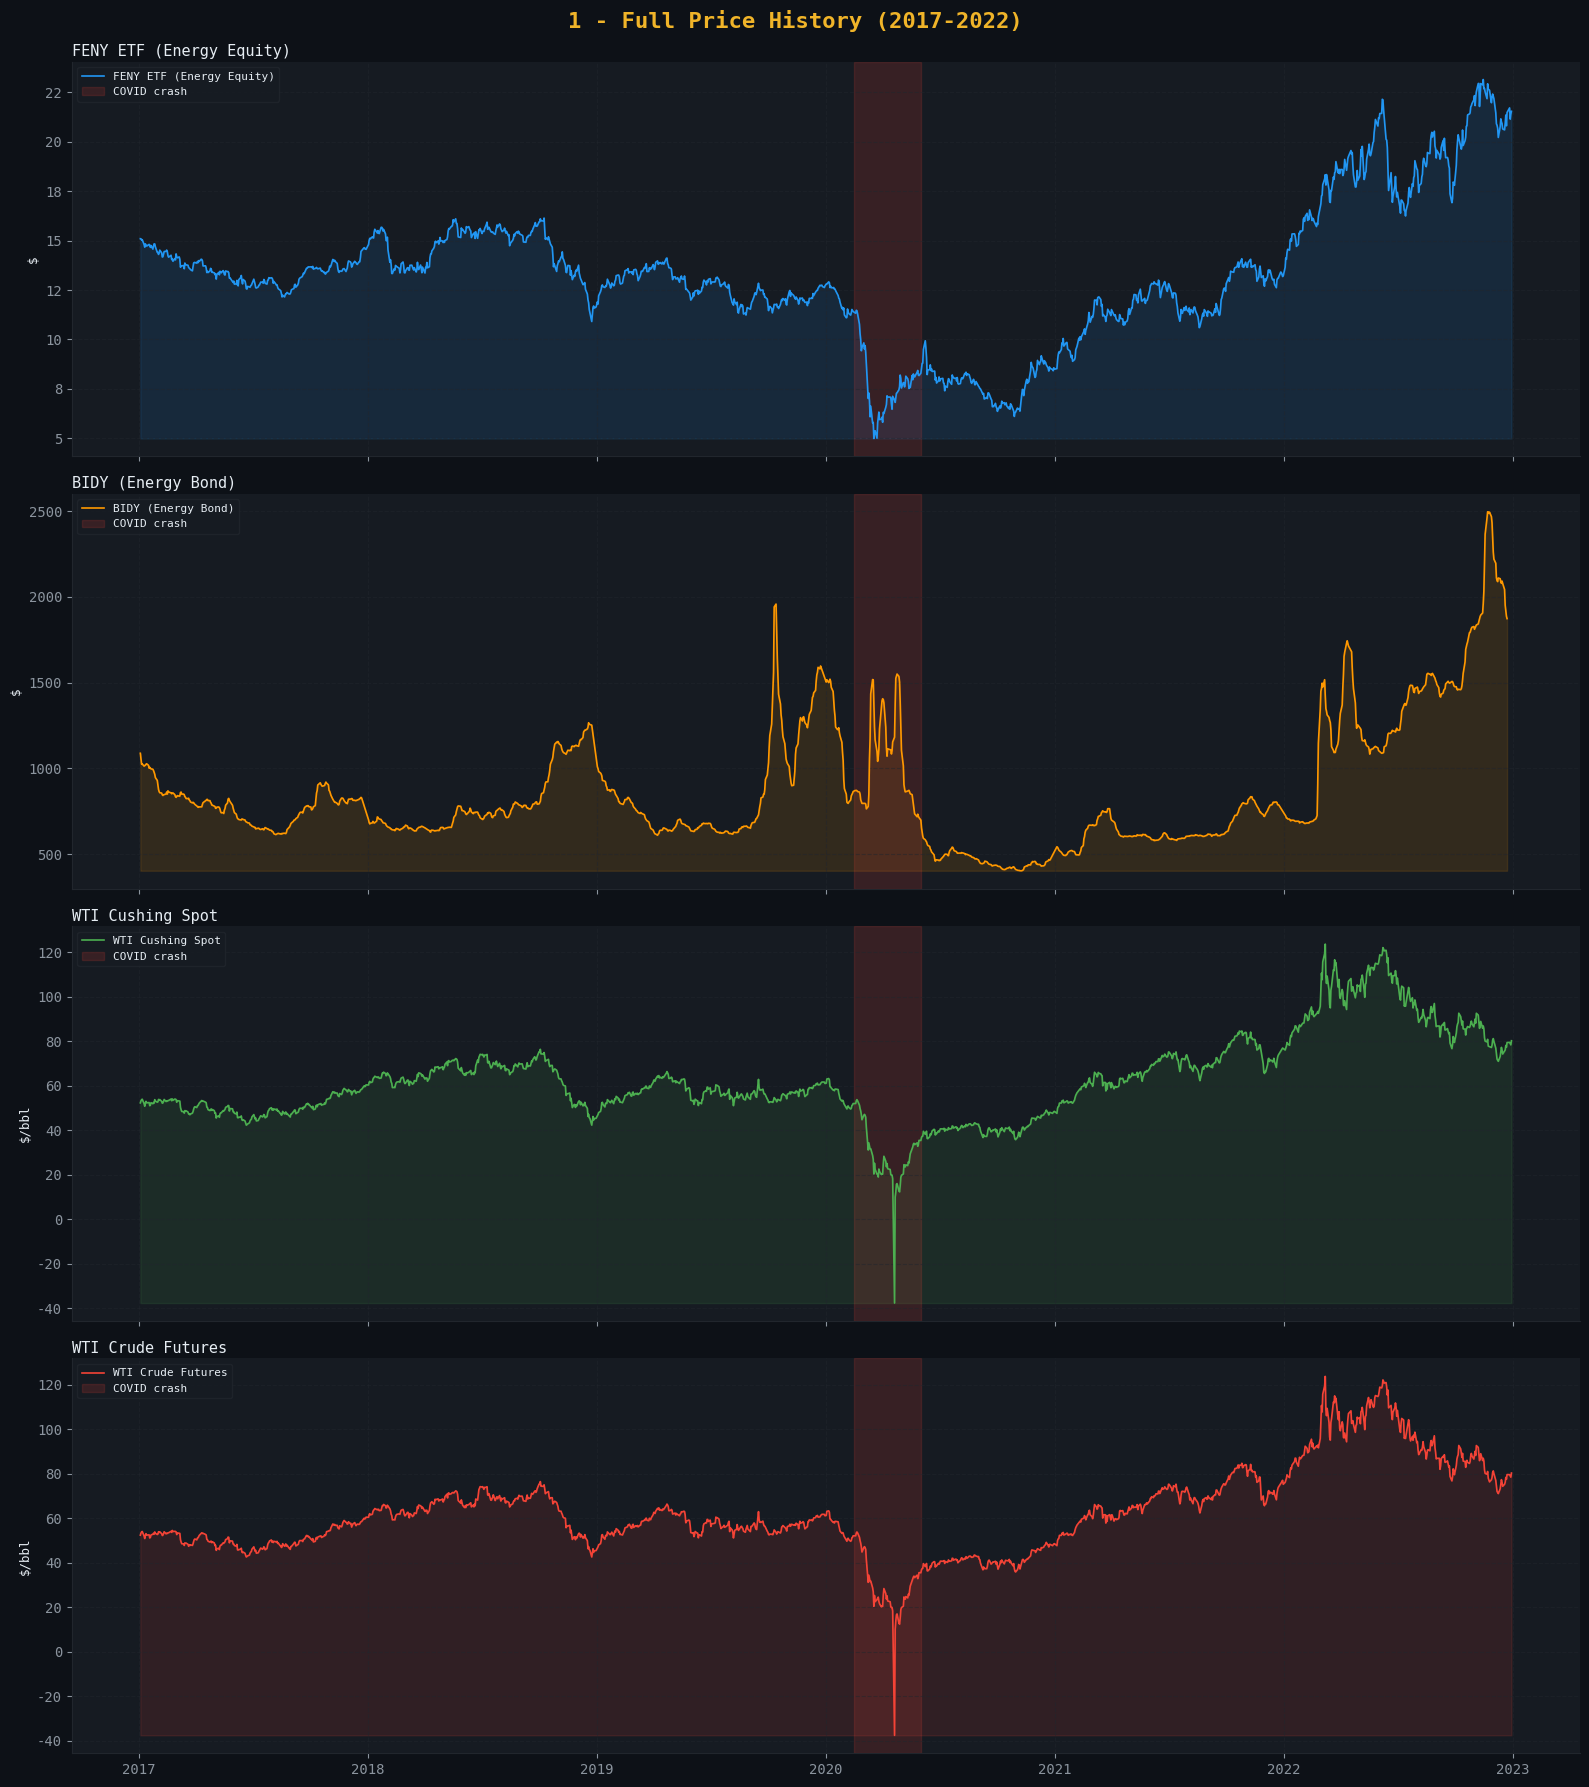

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig.suptitle("1 - Full Price History (2017-2022)", fontsize=16,
             color=C["accent"], fontweight="bold", y=0.99)

pairs = [
    ("feny", "FENY ETF (Energy Equity)", C["feny"], "$"),
    ("bidy", "BIDY (Energy Bond)", C["bidy"], "$"),
    ("wti_cushing", "WTI Cushing Spot", C["wti_c"], "$/bbl"),
    ("fut_price", "WTI Crude Futures", C["fut"], "$/bbl"),
]
for ax, (col, label, color, unit) in zip(axes, pairs):
    s = master[col].dropna()
    ax.plot(s.index, s, color=color, lw=1.2, label=label)
    ax.fill_between(s.index, s, s.min(), alpha=0.12, color=color)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(label, fontsize=11, loc="left", pad=4)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.grid(True)
    ax.axvspan(pd.Timestamp("2020-02-15"), pd.Timestamp("2020-06-01"),
               alpha=0.15, color="#F44336", label="COVID crash")
    ax.legend(fontsize=8, loc="upper left")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "01_price_history.png")
plt.show()

This shows the historical prices data for energy sector (FENY), energy bond (BIDY), WTI Cushing spot, and WTI futures.
The shaded region represents the COVID demand-crash window from Feb to June 2020.

## 2. WTI Cushing vs Midland spread

NOTE to self:
- Cushing is the NYMEX delivery hub in Oklahoma
- Midland is the Permian basin benchmark

  saved -> outputs\02_wti_spread.png


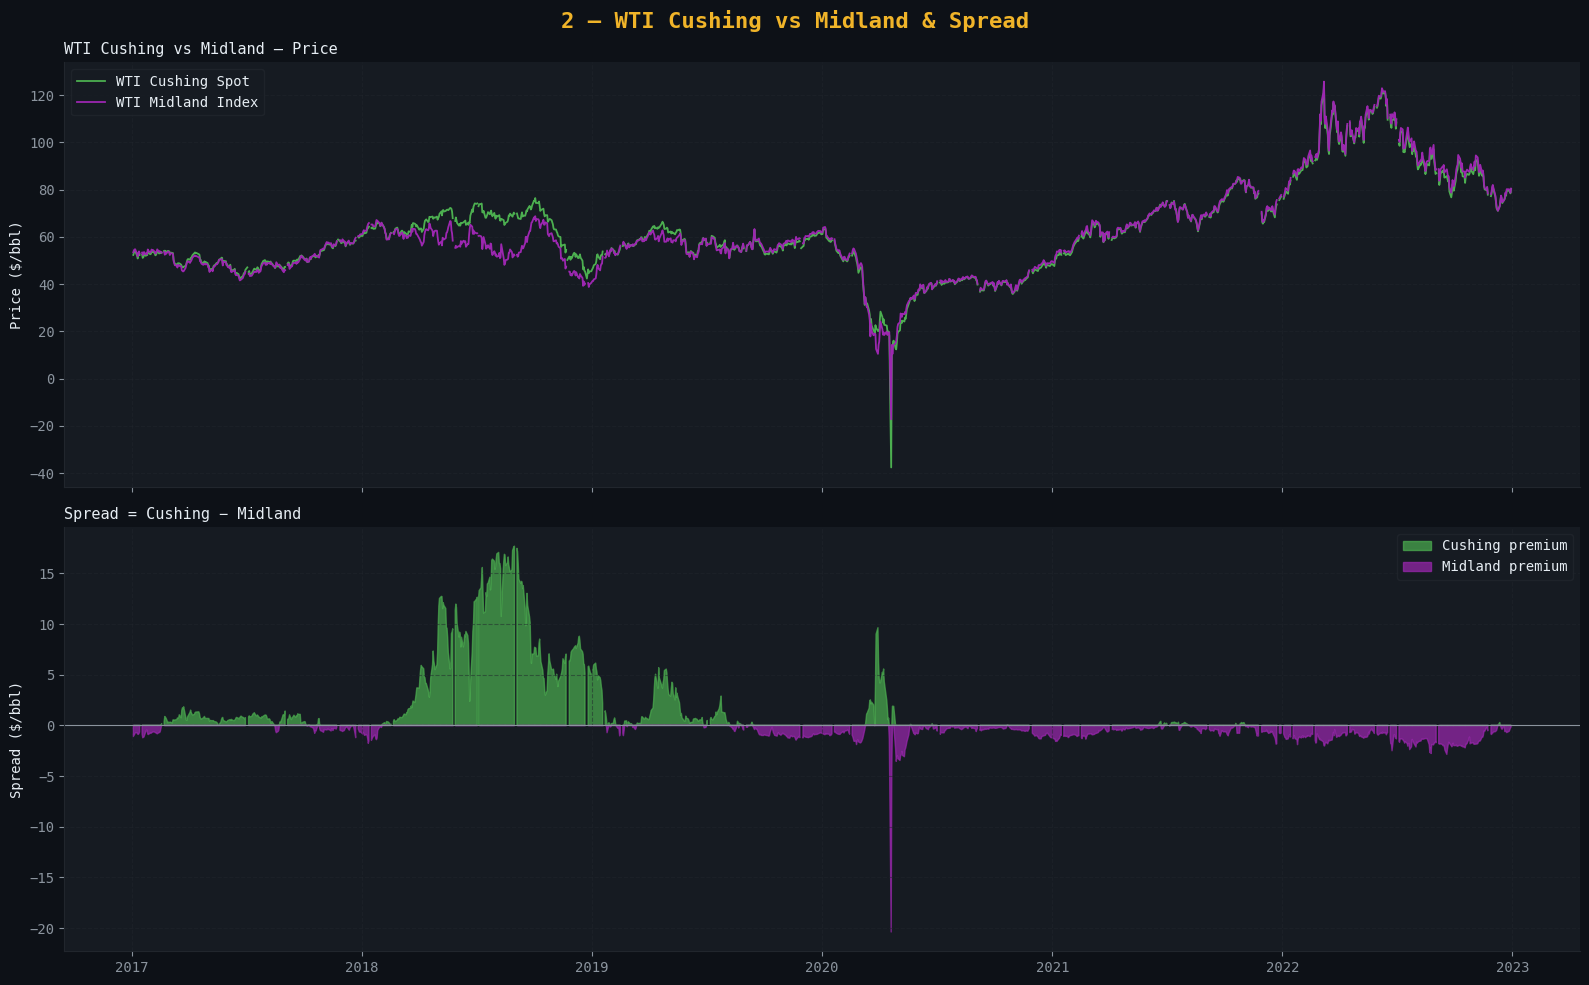

In [11]:
spread = master["wti_cushing"] - master["wti_midland"]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle("2 — WTI Cushing vs Midland & Spread", fontsize=16,
             color=C["accent"], fontweight="bold")

ax = axes[0]
ax.plot(master.index, master["wti_cushing"], color=C["wti_c"], lw=1.3, label="WTI Cushing Spot")
ax.plot(master.index, master["wti_midland"], color=C["wti_m"], lw=1.3, label="WTI Midland Index")
ax.set_ylabel("Price ($/bbl)"); ax.legend(); ax.grid(True)
ax.set_title("WTI Cushing vs Midland — Price", loc="left", fontsize=11)

ax = axes[1]
pos = spread.clip(lower=0)
neg = spread.clip(upper=0)
ax.fill_between(spread.index, pos, 0, color=C["wti_c"], alpha=0.7, label="Cushing premium")
ax.fill_between(spread.index, neg, 0, color=C["wti_m"], alpha=0.7, label="Midland premium")
ax.axhline(0, color=C["muted"], lw=0.8)
ax.set_ylabel("Spread ($/bbl)"); ax.legend(); ax.grid(True)
ax.set_title("Spread = Cushing − Midland", loc="left", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save(fig, "02_wti_spread.png")
plt.show()

Clearly, we see the spread premium correlation for Cushing vs Midland.
- The spread between Cushing and Midland tracks midstream constraints
- When Permian takeaway tightens, Midland trades at a discount to Cushing

## 3. Daily returns and rolling volatility

  saved -> outputs\03_returns_volatility.png


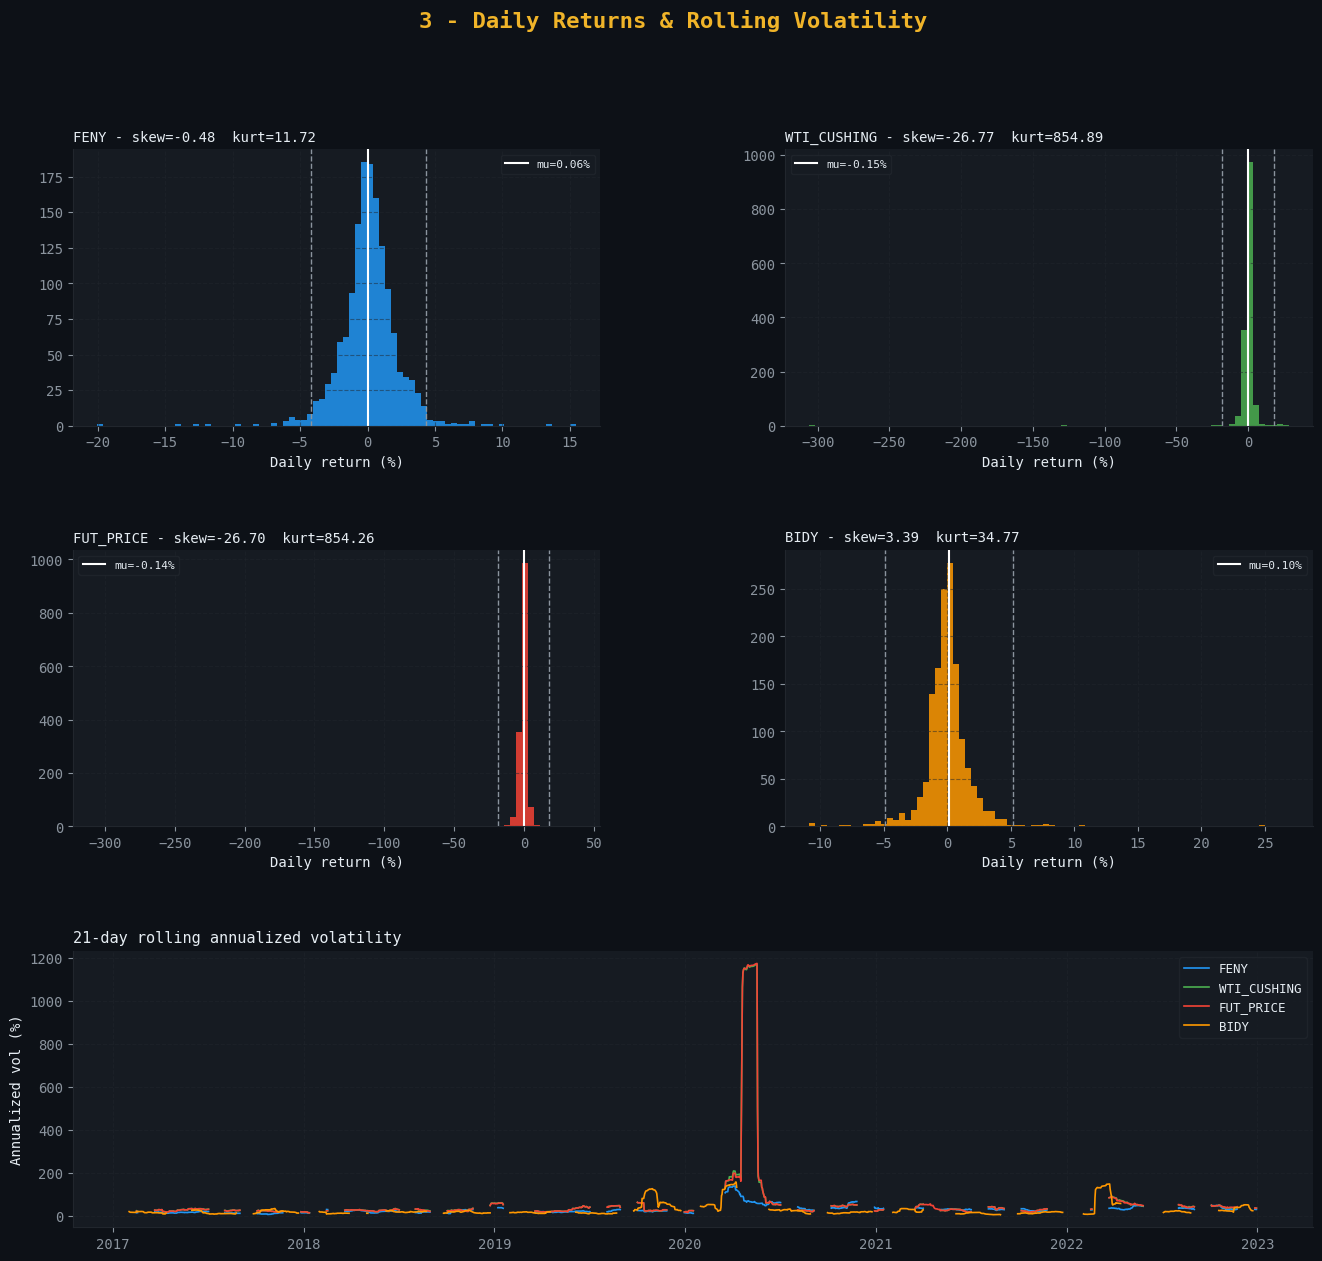

In [13]:
rets = master[["feny", "wti_cushing", "fut_price", "bidy"]].pct_change().dropna(how="all")
roll_vol = rets.rolling(21).std() * np.sqrt(252) * 100 # annualized in percentage

cols_ret = {
    "feny": C["feny"],
    "wti_cushing": C["wti_c"],
    "fut_price": C["fut"],
    "bidy": C["bidy"],
}

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("3 - Daily Returns & Rolling Volatility", fontsize=16, color=C["accent"], fontweight="bold")

# Distribution grid
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (col, color), (r, c) in zip(cols_ret.items(), positions):
    ax = fig.add_subplot(gs[r, c])
    s = rets[col].dropna()
    ax.hist(s * 100, bins=80, color=color, alpha=0.85, edgecolor="none")
    mu, sd = s.mean() * 100, s.std() * 100
    ax.axvline(mu, color="white", lw=1.5, label=f"mu={mu:.2f}%")
    ax.axvline(mu - 2*sd, color=C["muted"], lw=1, ls="--")
    ax.axvline(mu + 2*sd, color=C["muted"], lw=1, ls="--")
    sk, ku = stats.skew(s), stats.kurtosis(s)
    ax.set_title(f"{col.upper()} - skew={sk:.2f}  kurt={ku:.2f}", fontsize=10, loc="left")
    ax.set_xlabel("Daily return (%)")
    ax.legend(fontsize=8); ax.grid(True)

# Rolling vol panel
ax = fig.add_subplot(gs[2, :])
for col, color in cols_ret.items():
    ax.plot(roll_vol.index, roll_vol[col], color=color, lw=1.2, label=col.upper())
ax.set_ylabel("Annualized vol (%)")
ax.set_title("21-day rolling annualized volatility", loc="left", fontsize=11)
ax.legend(fontsize=9); ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

save(fig, "03_returns_volatility.png")
plt.show()

The four graphs a the top show the return distributions of the previously mentioned four core assets. Vertical lines are drawn at the mean and ±2σ bands away from the mean. The skewness and kurtosis are also included at the top.

NOTE: WTI Cushing and Futures prices have large outlier numbers. The crude futures distribution is also materially fatter-tailed than equity returns. And lastly, the kurtosis spike shows up for the April 2020 negative price period, as mentioned during the case study in class lecture.

The bottom graphs shows the 21-day rolling annualized volatility, where volatility is σ × √252 × 100

## 4. ETF oil correlation matrix and per-ETF correlation with WTI

Daily-return correlations between all ten energy ETFs and the four oil
benchmarks (WTI Cushing, WTI Midland, WTI futures, BIDY)

  saved -> outputs\04_correlations.png


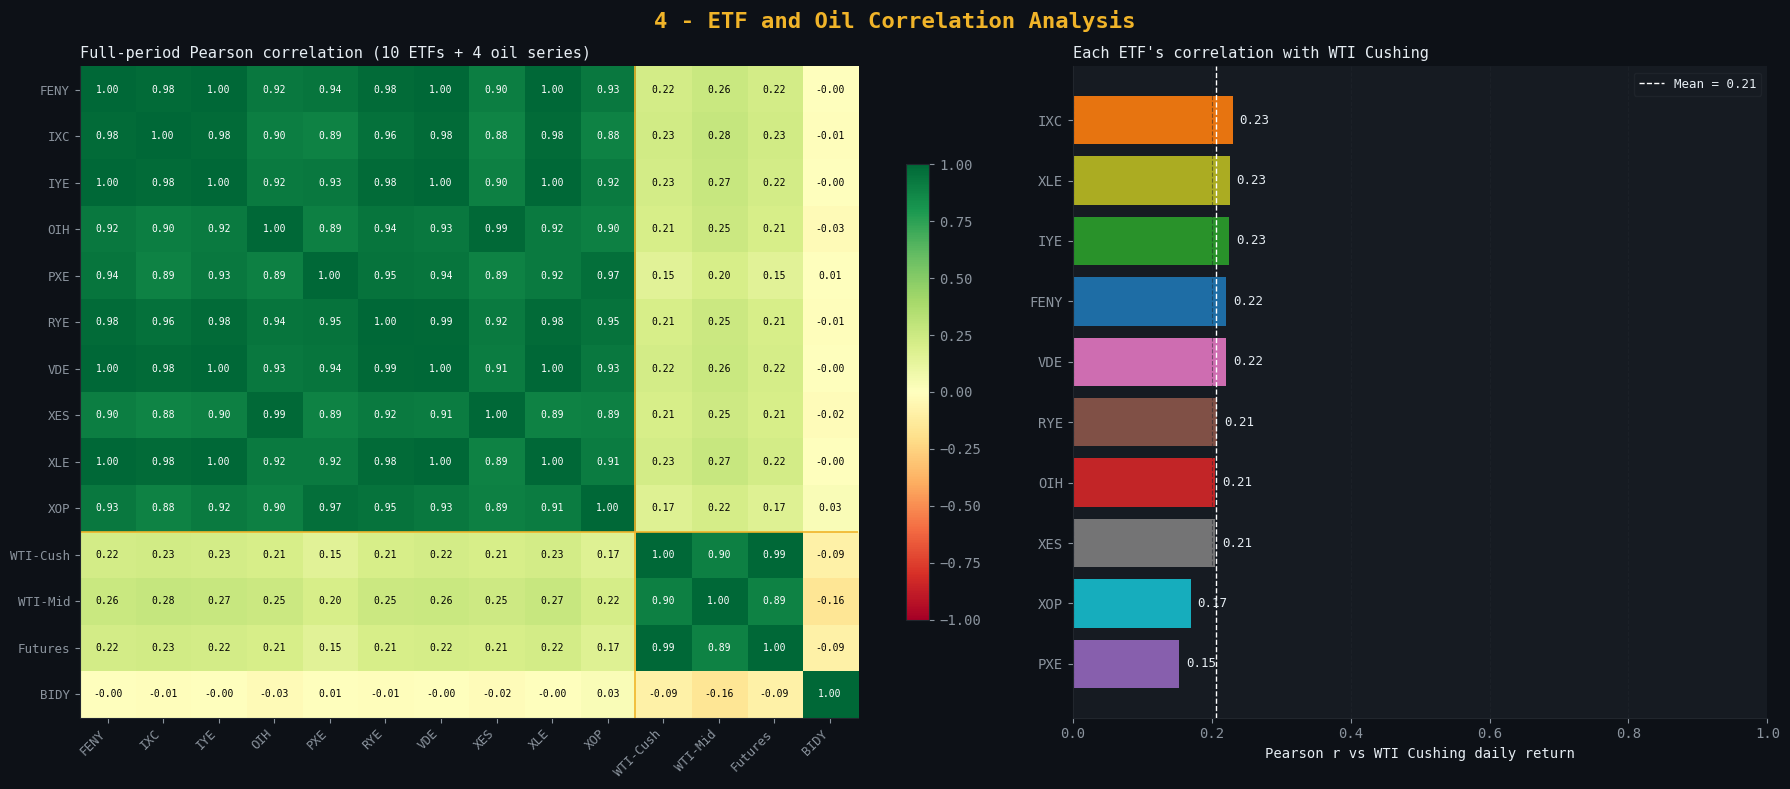

In [14]:
# Build a combined daily-return frame: 10 ETFs and 4 oil series
oil_for_corr = master[["wti_cushing", "wti_midland", "fut_price", "bidy"]]
combined_px  = etf_window.join(oil_for_corr, how="inner")
combined_rets = combined_px.pct_change().dropna(how="all")
corr_mat = combined_rets.corr()

# Friendly column order: ETFs first, then oil
oil_labels = {"wti_cushing": "WTI-Cush", "wti_midland": "WTI-Mid",
                "fut_price": "Futures", "bidy": "BIDY"}
order = ETFS + list(oil_labels.keys())
display_lbl = ETFS + [oil_labels[c] for c in oil_labels]
corr_mat = corr_mat.loc[order, order]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.4, 1]})
fig.suptitle("4 - ETF and Oil Correlation Analysis",
             fontsize=16, color=C["accent"], fontweight="bold")

# Heatmap
ax = axes[0]
im = ax.imshow(corr_mat.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(display_lbl)))
ax.set_yticks(range(len(display_lbl)))
ax.set_xticklabels(display_lbl, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(display_lbl, fontsize=9)
for i in range(len(display_lbl)):
    for j in range(len(display_lbl)):
        v = corr_mat.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(v) < 0.6 else "white")
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_title("Full-period Pearson correlation (10 ETFs + 4 oil series)",
             fontsize=11, loc="left")
# visual separator between ETF block and oil block
ax.axhline(len(ETFS) - 0.5, color=C["accent"], lw=1.2)
ax.axvline(len(ETFS) - 0.5, color=C["accent"], lw=1.2)

# Per-ETF correlation with WTI Cushing
etf_vs_wti = combined_rets[ETFS].corrwith(combined_rets["wti_cushing"]).sort_values(ascending=True)

ax = axes[1]
bar_colors = [etf_colors[t] for t in etf_vs_wti.index]
ax.barh(etf_vs_wti.index, etf_vs_wti.values, color=bar_colors, alpha=0.9)
ax.axvline(etf_vs_wti.mean(), color="white", lw=1, ls="--",
           label=f"Mean = {etf_vs_wti.mean():.2f}")
ax.set_xlim(0, 1)
ax.set_xlabel("Pearson r vs WTI Cushing daily return")
ax.set_title("Each ETF's correlation with WTI Cushing", fontsize=11, loc="left")
ax.grid(True, axis="x")
ax.legend(fontsize=9)
for i, v in enumerate(etf_vs_wti.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9, color=C["text"])

fig.tight_layout()
save(fig, "04_correlations.png")
plt.show()

On the left, a correlation heatmap covering ETFs and oil series is shown. Block structure on the diagonal shows that ETFs are tightly correlated to one another (~0.9) but only moderately to the underlying oil benchmarks (~0.5–0.7).

On the right, a bar chart of each ETF's full-period correlation with WTI Cushing, sorted from strongest to weakest, is shown.

## 5. DOE inventory vs futures price

  saved -> outputs\05_inventory_vs_price.png


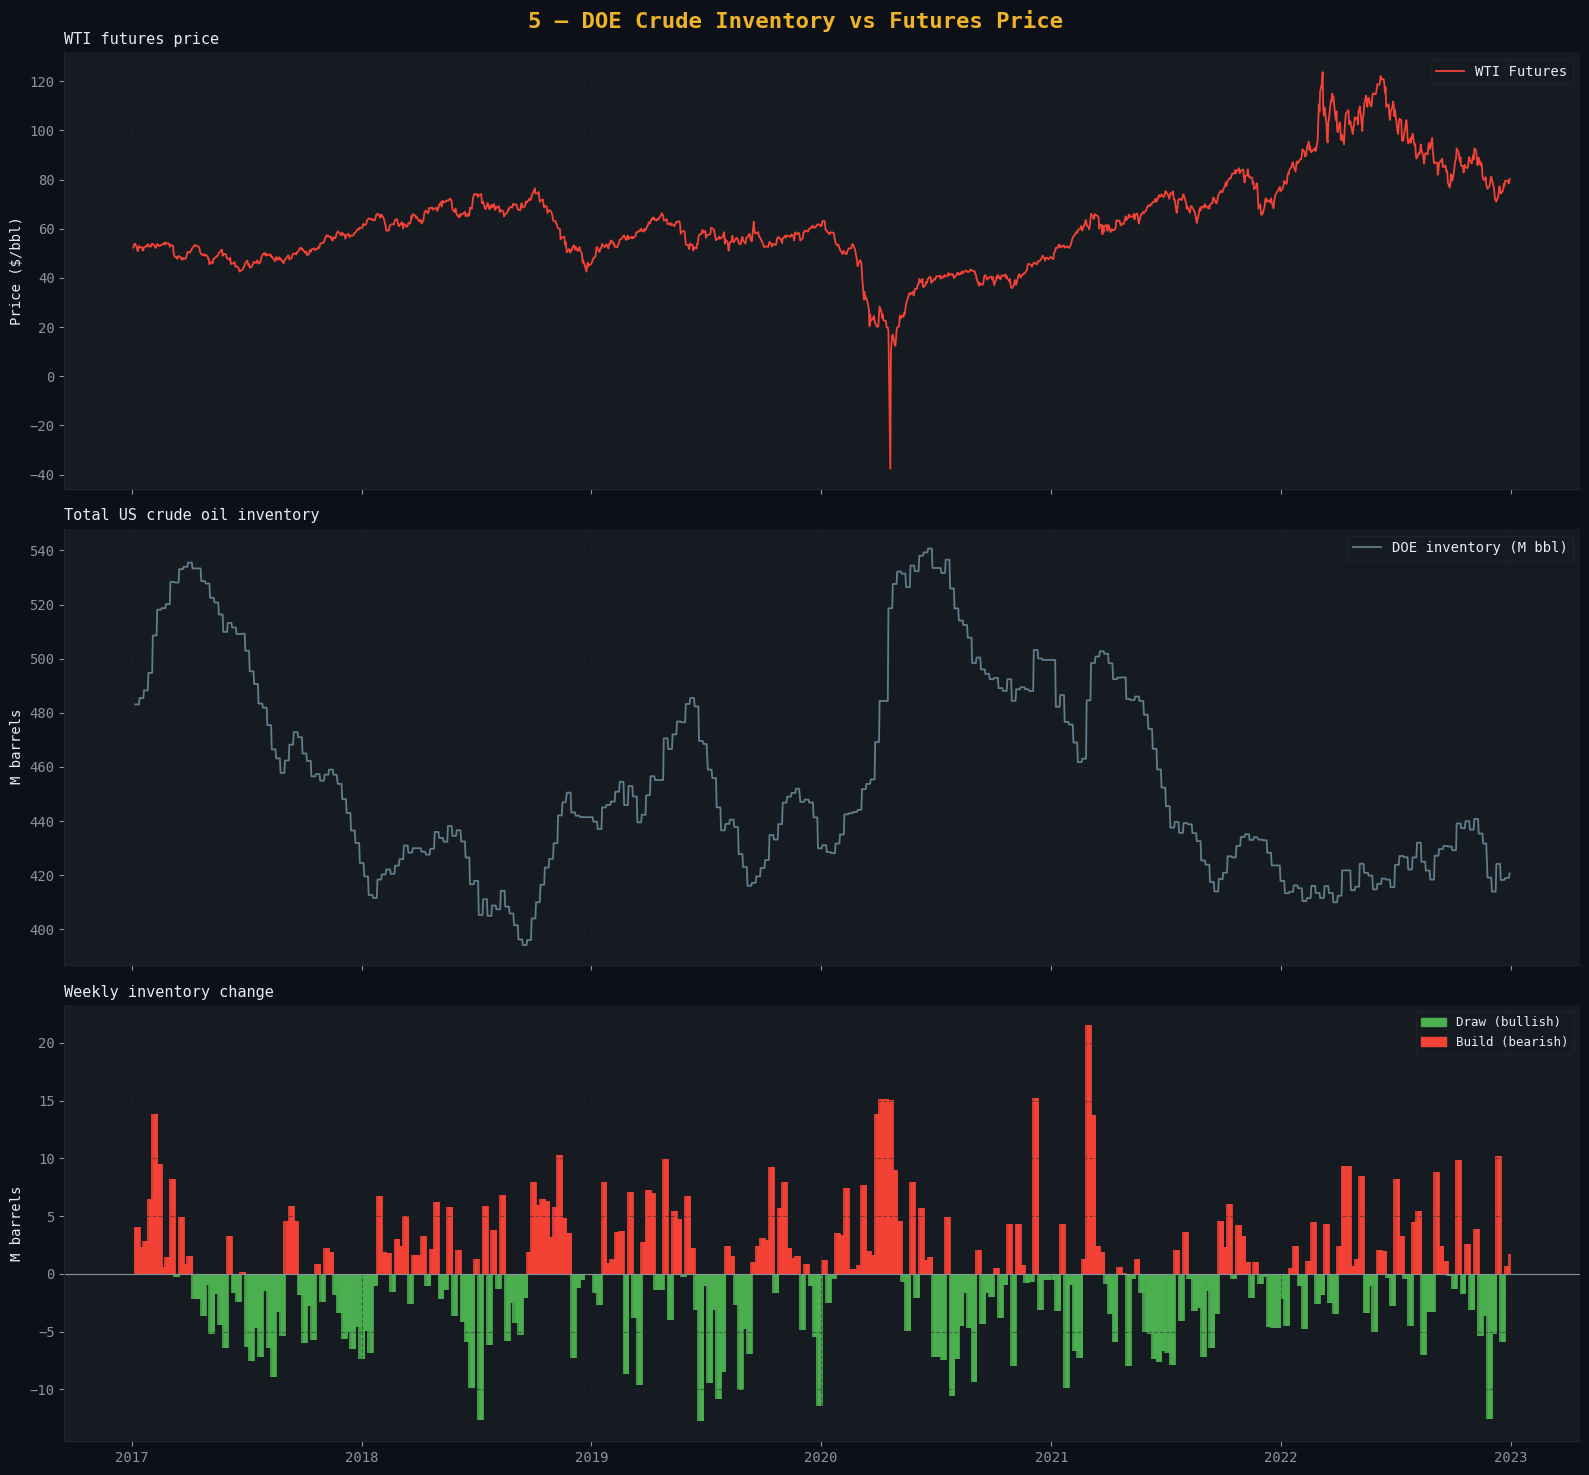

In [ ]:
combined = (fut[["Date", "fut_price"]]
            .set_index("Date")
            .join(inv_w, how="left")
            .join(inv_ch_w, how="left")
            .loc[START:END]
            .dropna(subset=["fut_price"]))

# weekly series carried forward to daily index
combined["inventory"]  = combined["inventory"].ffill()
combined["inv_change"] = combined["inv_change"].ffill()

fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)
fig.suptitle("5 - DOE Crude Inventory vs Futures Price",
             fontsize=16, color=C["accent"], fontweight="bold")

axes[0].plot(combined.index, combined["fut_price"], color=C["fut"], lw=1.3, label="WTI Futures")
axes[0].set_ylabel("Price ($/bbl)"); axes[0].legend(); axes[0].grid(True)
axes[0].set_title("WTI futures price", loc="left", fontsize=11)

axes[1].plot(combined.index, combined["inventory"] / 1e3, color=C["inv"], lw=1.3, label="DOE inventory (M bbl)")
axes[1].set_ylabel("M barrels"); axes[1].legend(); axes[1].grid(True)
axes[1].set_title("Total US crude oil inventory", loc="left", fontsize=11)

ic = combined["inv_change"].dropna()
bar_colors = [C["wti_c"] if v < 0 else C["fut"] for v in ic]
axes[2].bar(ic.index, ic / 1e3, color=bar_colors, width=5, alpha=0.85)
axes[2].axhline(0, color=C["muted"], lw=0.8)
axes[2].set_ylabel("M barrels"); axes[2].grid(True)
axes[2].legend(handles=[Patch(color=C["wti_c"], label="Draw (bullish)"),
                        Patch(color=C["fut"],   label="Build (bearish)")], fontsize=9)
axes[2].set_title("Weekly inventory change", loc="left", fontsize=11)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save(fig, "05_inventory_vs_price.png")
plt.show()

This section graphs the DOE Crude Inventory to the Futures prices.
From top to bottom, the graphs show WTI futures price, total US crude oil inventory, and weekly inventory change. Whenever inventory increases, there is an increase in supply, so decrease in demand. This means the prices drop and become bearish (hence graphed in red). The opposite is true for when supply is low, demand surges, and price raise for green bullish prices.

## 6. Futures market microstructure

  saved -> outputs\06_futures_oi_volume.png


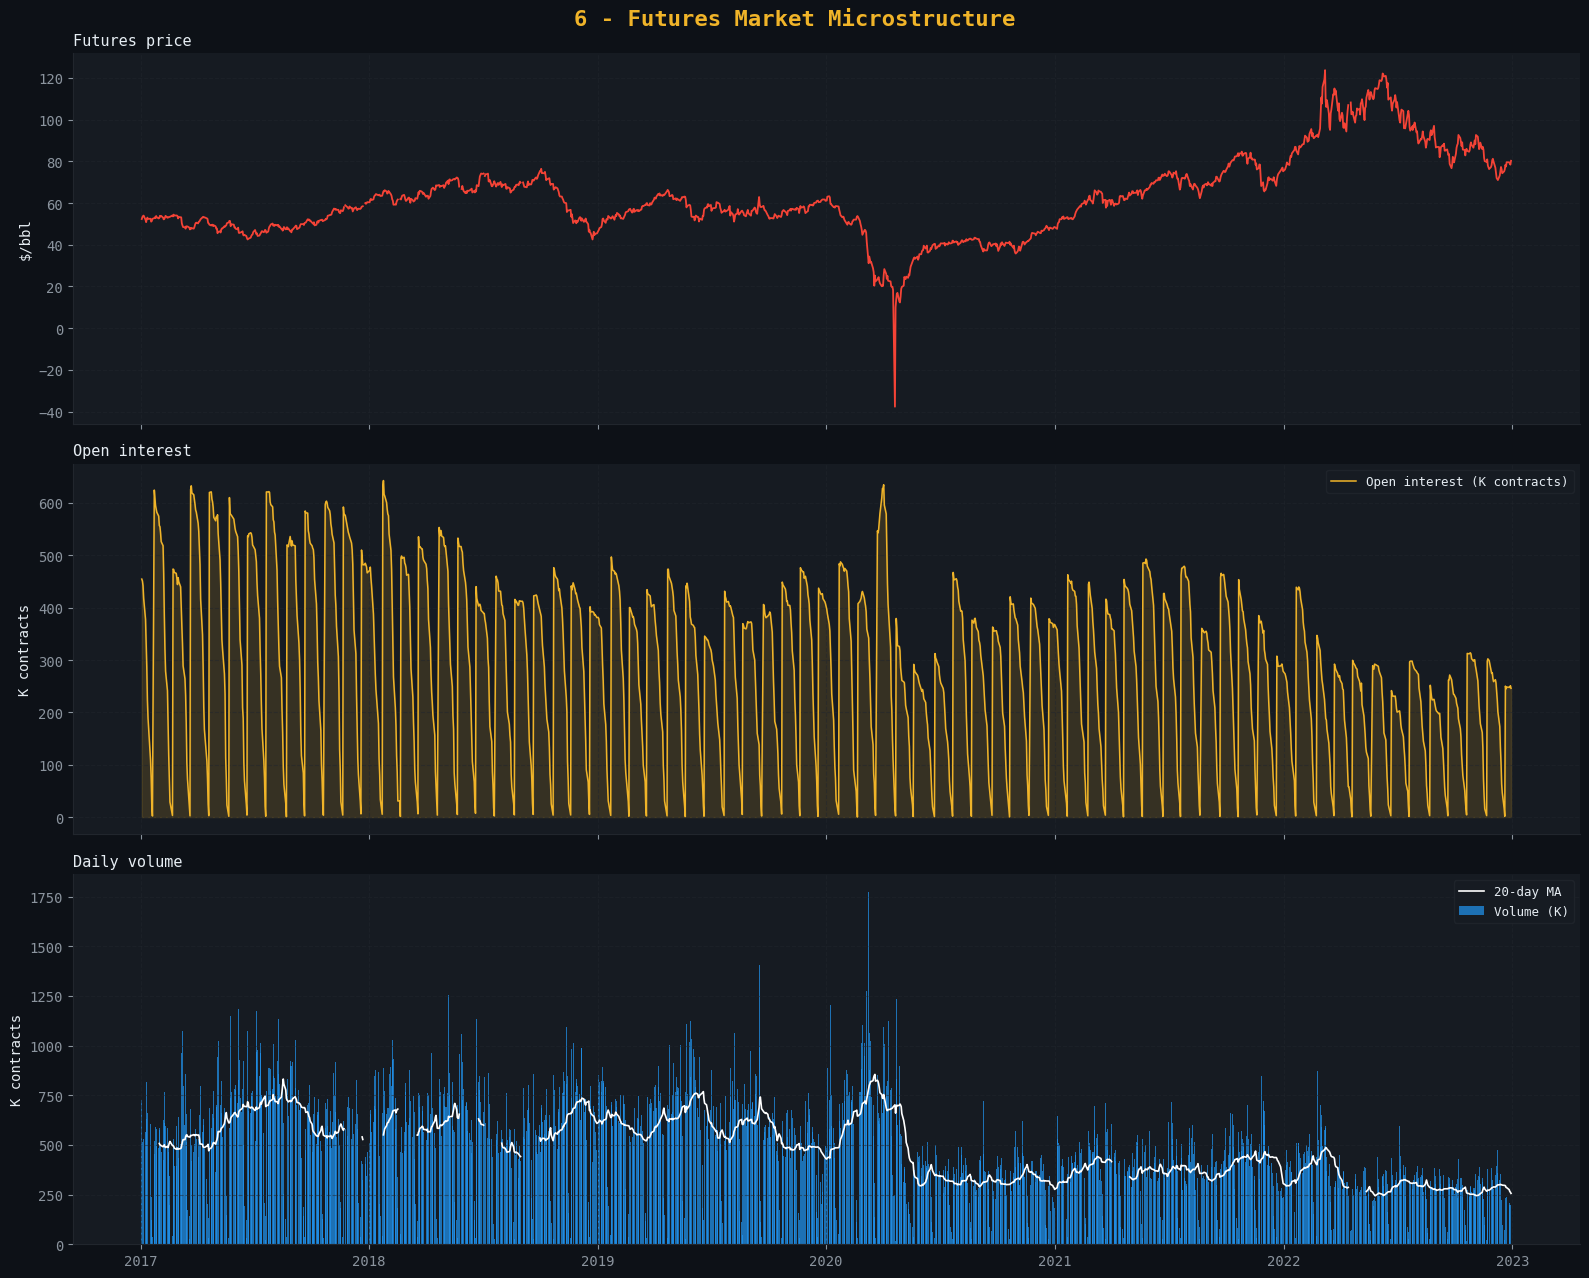

In [16]:
f = fut.set_index("Date").loc[START:END]

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
fig.suptitle("6 - Futures Market Microstructure", fontsize=16,
             color=C["accent"], fontweight="bold")

axes[0].plot(f.index, f["fut_price"], color=C["fut"], lw=1.3)
axes[0].set_ylabel("$/bbl"); axes[0].grid(True)
axes[0].set_title("Futures price", loc="left", fontsize=11)

axes[1].plot(f.index, f["open_int"] / 1e3, color=C["accent"], lw=1.1, label="Open interest (K contracts)")
axes[1].fill_between(f.index, f["open_int"] / 1e3, 0, alpha=0.15, color=C["accent"])
axes[1].set_ylabel("K contracts"); axes[1].legend(fontsize=9); axes[1].grid(True)
axes[1].set_title("Open interest", loc="left", fontsize=11)

axes[2].bar(f.index, f["fut_vol"] / 1e3, color=C["feny"], alpha=0.7, width=1.5, label="Volume (K)")
axes[2].plot(f.index, f["fut_vol"].rolling(20).mean() / 1e3, color="white", lw=1.2, label="20-day MA")
axes[2].set_ylabel("K contracts"); axes[2].legend(fontsize=9); axes[2].grid(True)
axes[2].set_title("Daily volume", loc="left", fontsize=11)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save(fig, "06_futures_oi_volume.png")
plt.show()

Next, we examine the price vs open interest vs volume.
Immediately, we see a sharp rise and drop in open interest. This follow the logic that oil futures are quoted monthly and their positions rolled also on a monthly basis, hence the constant oscillation in demand. Open interest (total outstanding contracts) and daily volume reveal positioning
and participation. Volume spikes mark days of forced rebalancing. In the daily volume, we see some abnormalities around early/mid 2020 and a decreased volume in hte years following.

## 7. Rolling beta for each ETF vs WTI Cushing

  saved -> outputs\07_rolling_beta.png


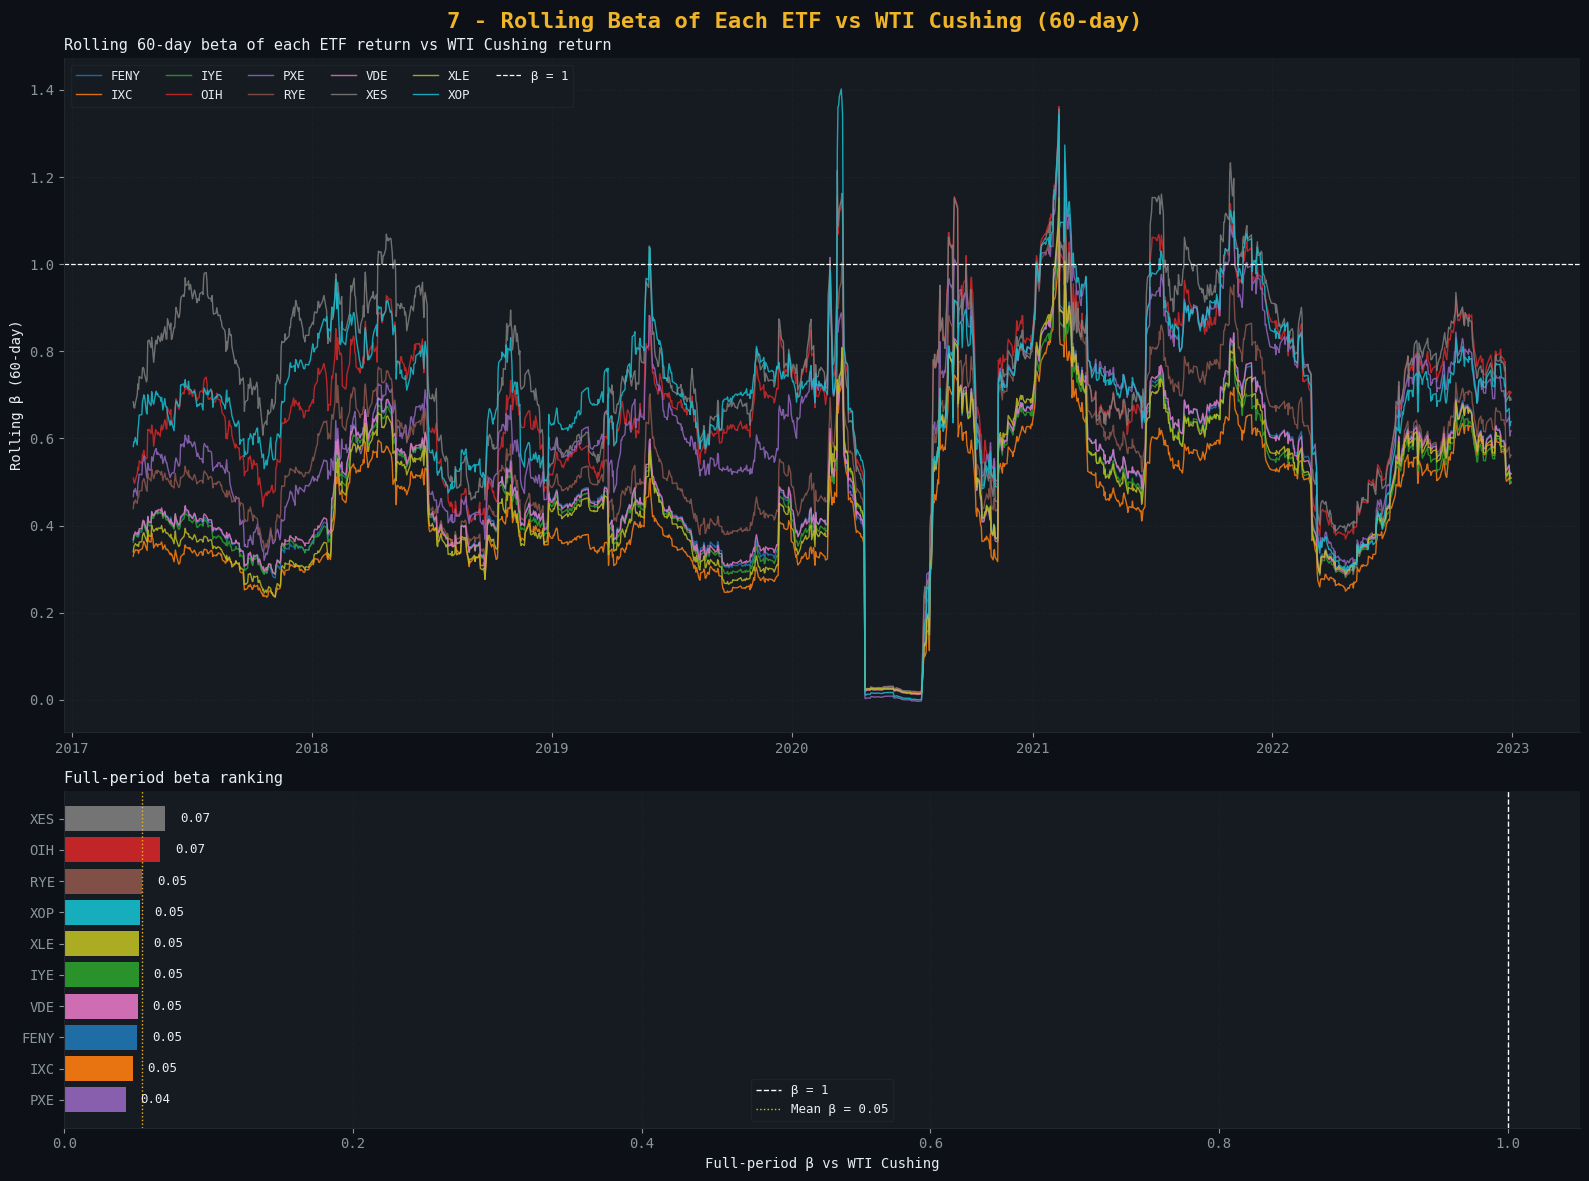

In [21]:
def rolling_beta(y: pd.Series, x: pd.Series, window: int) -> pd.Series:
    # Rolling univariate OLS slope of y on x.
    out_idx, out_val = [], []
    for i in range(window, len(y)):
        yy = y.iloc[i - window:i].values
        xx = x.iloc[i - window:i].values
        mask = ~(np.isnan(yy) | np.isnan(xx))
        if mask.sum() < 20:
            out_val.append(np.nan)
        else:
            b, _, _, _, _ = stats.linregress(xx[mask], yy[mask])
            out_val.append(b)
        out_idx.append(y.index[i])
    return pd.Series(out_val, index=out_idx)

# Align ETF returns and WTI returns
wti_r = master["wti_cushing"].pct_change()
etf_r = etf_window.pct_change()
common_idx = wti_r.dropna().index.intersection(etf_r.dropna(how="all").index)
wti_r = wti_r.loc[common_idx]
etf_r = etf_r.loc[common_idx]

# Rolling betas (one Series per ETF) and full-period betas
WIN = 60
roll_betas = {t: rolling_beta(etf_r[t], wti_r, WIN) for t in ETFS}
roll_betas = pd.DataFrame(roll_betas).dropna(how="all")

full_betas = {}
for t in ETFS:
    df = pd.concat([wti_r, etf_r[t]], axis=1).dropna()
    full_betas[t] = stats.linregress(df.iloc[:, 0], df.iloc[:, 1]).slope
full_betas = pd.Series(full_betas).sort_values(ascending=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                         gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("7 - Rolling Beta of Each ETF vs WTI Cushing (60-day)",
             fontsize=16, color=C["accent"], fontweight="bold")

# Top: rolling beta lines
ax = axes[0]
for t in ETFS:
    ax.plot(roll_betas.index, roll_betas[t], lw=1.0, alpha=0.85,
            color=etf_colors[t], label=t)
ax.axhline(1, color="white", lw=0.9, ls="--", label="β = 1")
ax.set_ylabel("Rolling β (60-day)")
ax.set_title("Rolling 60-day beta of each ETF return vs WTI Cushing return",
             fontsize=11, loc="left")
ax.legend(fontsize=9, ncol=6, loc="upper left")
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Bottom: full-period beta bar ranking
ax = axes[1]
bar_colors = [etf_colors[t] for t in full_betas.index]
ax.barh(full_betas.index, full_betas.values, color=bar_colors, alpha=0.9)
ax.axvline(1, color="white", lw=1, ls="--", label="β = 1")
ax.axvline(full_betas.mean(), color=C["accent"], lw=1, ls=":",
           label=f"Mean β = {full_betas.mean():.2f}")
ax.set_xlabel("Full-period β vs WTI Cushing")
ax.set_title("Full-period beta ranking", loc="left", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, axis="x")
for i, v in enumerate(full_betas.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9, color=C["text"])

fig.tight_layout()
save(fig, "07_rolling_beta.png")
plt.show()

For every ETF, beta is the slope from regressing the ETF's daily return on the
WTI Cushing daily return over a 60-trading-day window. This value is chosen to represent roughly one quarter of the fiscal year.

In the top graph showing the rolling betas, there is clearly a sharp drop during the COVID drop.

To analyze the beta value:
- β > 1 --> ETF amplifies oil moves. This is typical for OIH, XES, XOP oils tickers
- β < 1 --> ETF is partially insulated from oil. This is typical for large-cap or diversified ETFs like XLE, IXC

Each ETF's beta is then ranked in the botton graph.

## 8. Drawdown from all-time high

  saved -> outputs\08_drawdown.png


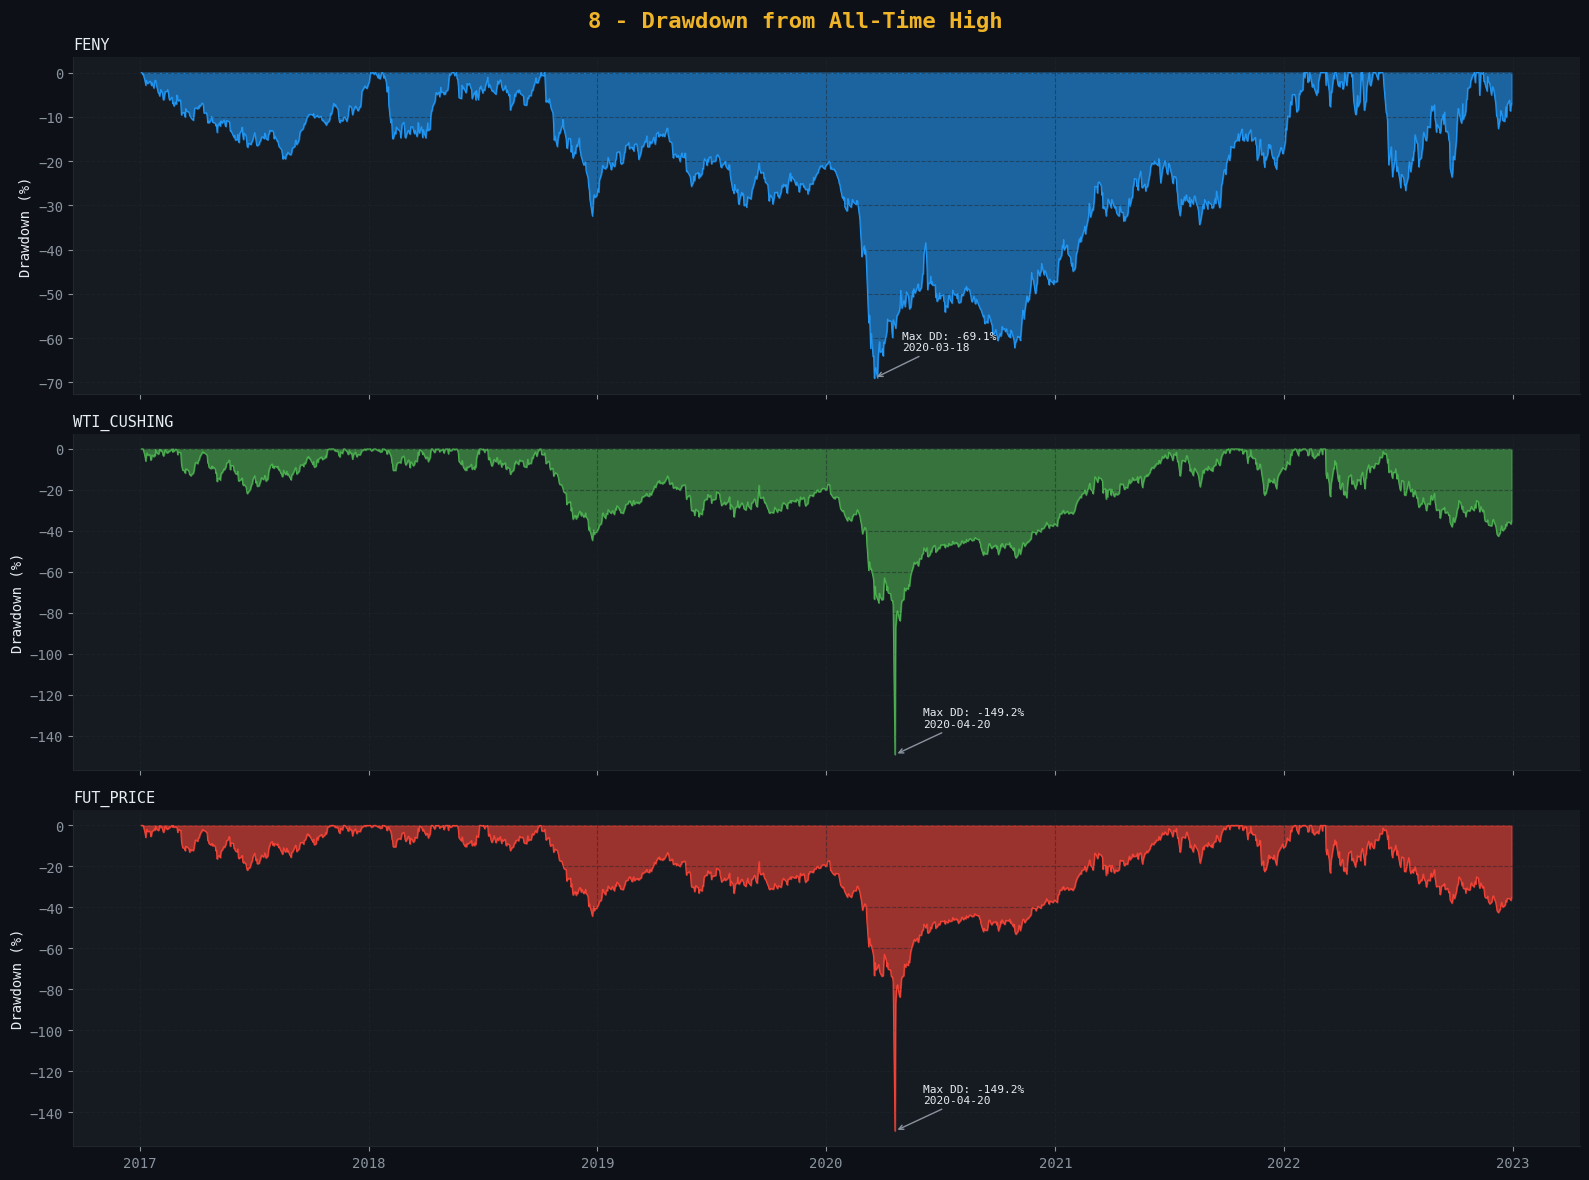

In [23]:
def max_drawdown_series(s: pd.Series):
    return (s - s.expanding().max()) / s.expanding().max() * 100

dd_cols = {"feny": C["feny"], "wti_cushing": C["wti_c"], "fut_price": C["fut"]}

fig, axes = plt.subplots(len(dd_cols), 1, figsize=(16, 12), sharex=True)
fig.suptitle("8 - Drawdown from All-Time High",
             fontsize=16, color=C["accent"], fontweight="bold")

for ax, (col, color) in zip(axes, dd_cols.items()):
    s  = master[col].dropna()
    dd = max_drawdown_series(s)
    ax.fill_between(dd.index, dd, 0, color=color, alpha=0.6)
    ax.plot(dd.index, dd, color=color, lw=0.8)
    ax.set_ylabel("Drawdown (%)")
    worst, when = dd.min(), dd.idxmin()
    ax.annotate(f"Max DD: {worst:.1f}%\n{when.date()}",
                xy=(when, worst), xytext=(20, 20),
                textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=C["muted"]),
                color=C["text"], fontsize=8)
    ax.set_title(col.upper(), loc="left", fontsize=11)
    ax.grid(True)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "08_drawdown.png")
plt.show()

$$Drawdown = \frac{(price − runningMax)}{runningMax}$$

The shaded area below zero is the percentage decline relative to the highest level seen so far. This emphasizes the negative impact from 2020.

## 9. Monthly-return to show sesasonal demands

  saved -> outputs\09_seasonality.png


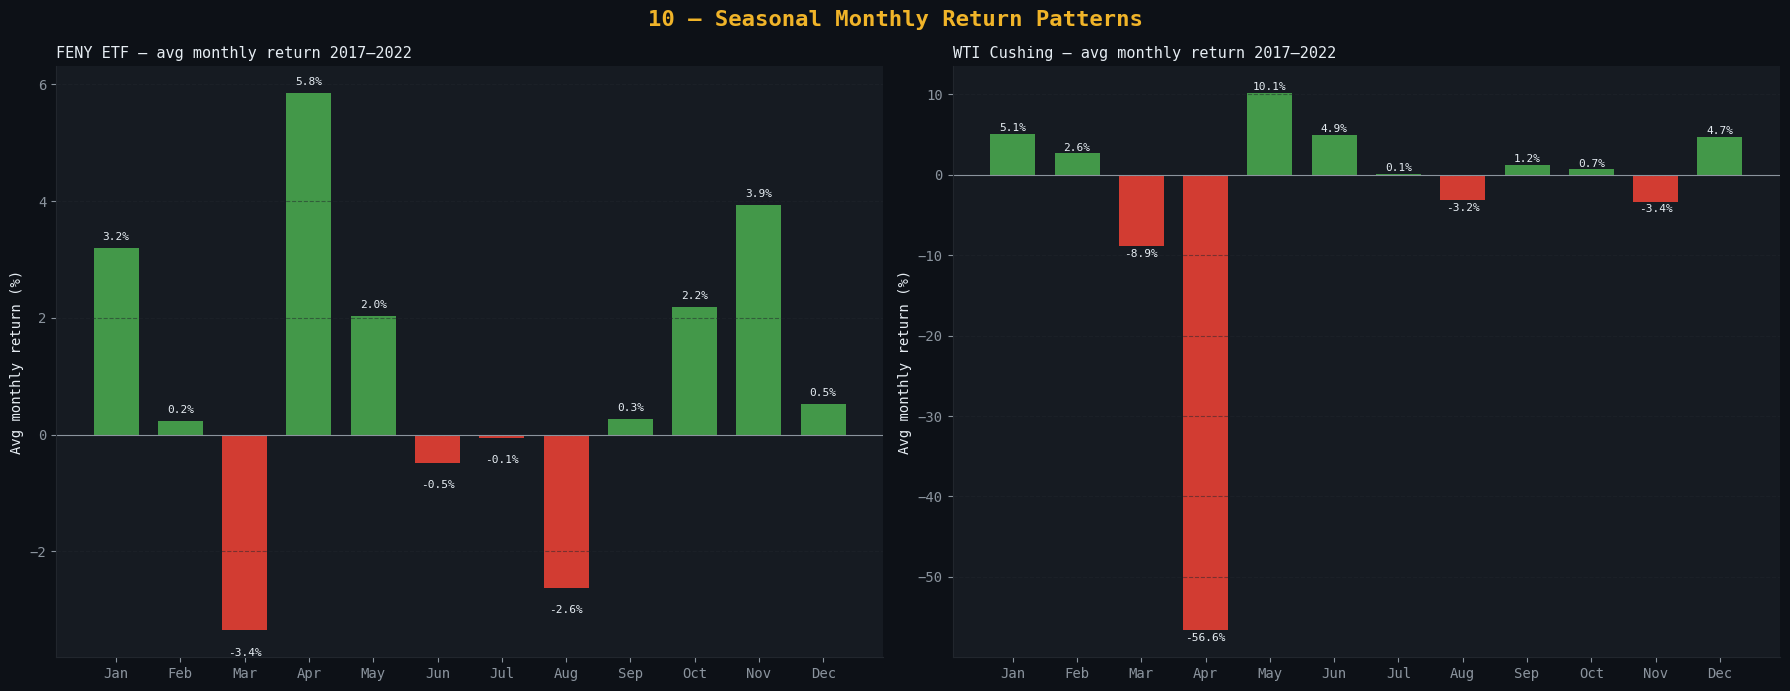

In [27]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def monthly_avg_return(series: pd.Series):
    s   = series.dropna()
    df  = pd.DataFrame({"ret": s.pct_change() * 100,
                        "year": s.index.year,
                        "month": s.index.month})
    pivot = df.groupby(["year", "month"])["ret"].sum().unstack("month")
    pivot.columns = [months[m - 1] for m in pivot.columns]
    return pivot.mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("10 — Seasonal Monthly Return Patterns",
             fontsize=16, color=C["accent"], fontweight="bold")

for ax, (col, label) in zip(axes, [("feny", "FENY ETF"),
                                   ("wti_cushing", "WTI Cushing")]):
    avg  = monthly_avg_return(master[col])
    x    = np.arange(len(avg))
    bars = ax.bar(x, avg.values,
                  color=[C["wti_c"] if v >= 0 else C["fut"] for v in avg.values],
                  alpha=0.85, width=0.7)
    ax.axhline(0, color=C["muted"], lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(avg.index.tolist(), fontsize=10)
    ax.set_ylabel("Avg monthly return (%)")
    ax.set_title(f"{label} — avg monthly return 2017–2022", loc="left", fontsize=11)
    ax.grid(True, axis="y")
    for bar, v in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (0.1 if v >= 0 else -0.3),
                f"{v:.1f}%", ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=8, color=C["text"])

fig.tight_layout()
save(fig, "09_seasonality.png")
plt.show()

Daily returns are summed and groupby'ed per month. This is to show the monthly demand over time, which happens to also show the seasonal demands of energy and oil.

## 10. Moving-average crossover signals

  saved -> outputs\10_ma_crossover.png


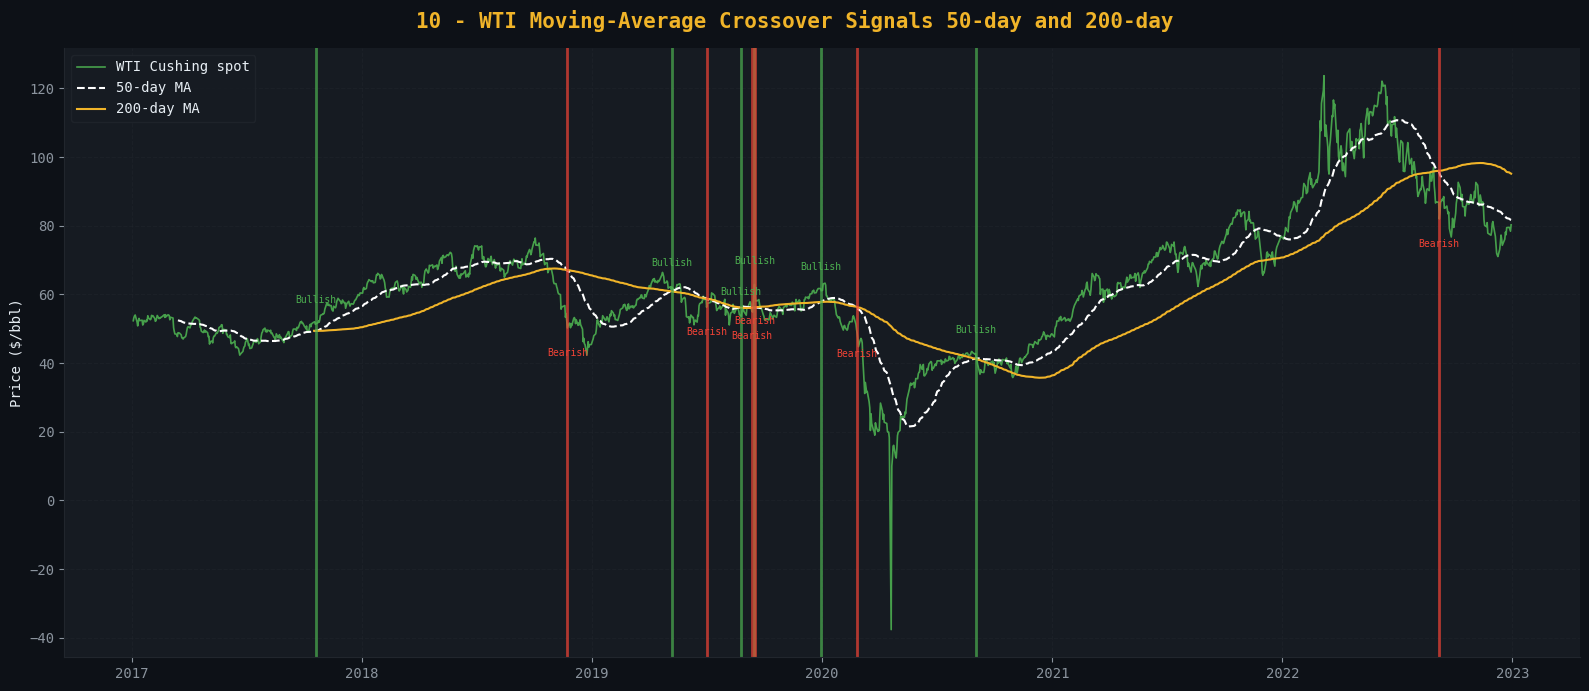

In [32]:
price = master["wti_cushing"].dropna()
ma50 = price.rolling(50).mean()
ma200 = price.rolling(200).mean()

cross = (ma50 > ma200).astype(int).diff()
golden = cross[cross == 1].index
death  = cross[cross == -1].index

price_at = price.reindex(golden.union(death), method="nearest") # look up prices at crossover dates

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle("10 - WTI Moving-Average Crossover Signals 50-day and 200-day",
             fontsize=15, color=C["accent"], fontweight="bold")

ax.plot(price.index, price, color=C["wti_c"], lw=1.2, alpha=0.9, label="WTI Cushing spot")
ax.plot(ma50.index, ma50, color="white",     lw=1.5, ls="--", label="50-day MA")
ax.plot(ma200.index, ma200, color=C["accent"], lw=1.5, label="200-day MA")

for g in golden:
    ax.axvline(g, color="#4CAF50", alpha=0.7, lw=2)
    ax.annotate("Bullish", xy=(g, price_at.loc[g]),
                xytext=(0, 15), textcoords="offset points",
                fontsize=7, color="#4CAF50", ha="center")

for d in death:
    ax.axvline(d, color="#F44336", alpha=0.7, lw=2)
    ax.annotate("Bearish", xy=(d, price_at.loc[d]),
                xytext=(0, -20), textcoords="offset points",
                fontsize=7, color="#F44336", ha="center")

ax.set_ylabel("Price ($/bbl)")
ax.legend(fontsize=10); ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save(fig, "10_ma_crossover.png")
plt.show()

The graph shows prices with their 50-day and 200-day moving averages.
Whenever the 50-day crosses over the 200-day line, a bullish trend signal is vertically graphed in green. On the other hand, red lines occur during bearish markets when the 50-day crosses under the 200-day line.

## 11. Annual returns by asset

  saved -> outputs\11_annual_returns.png


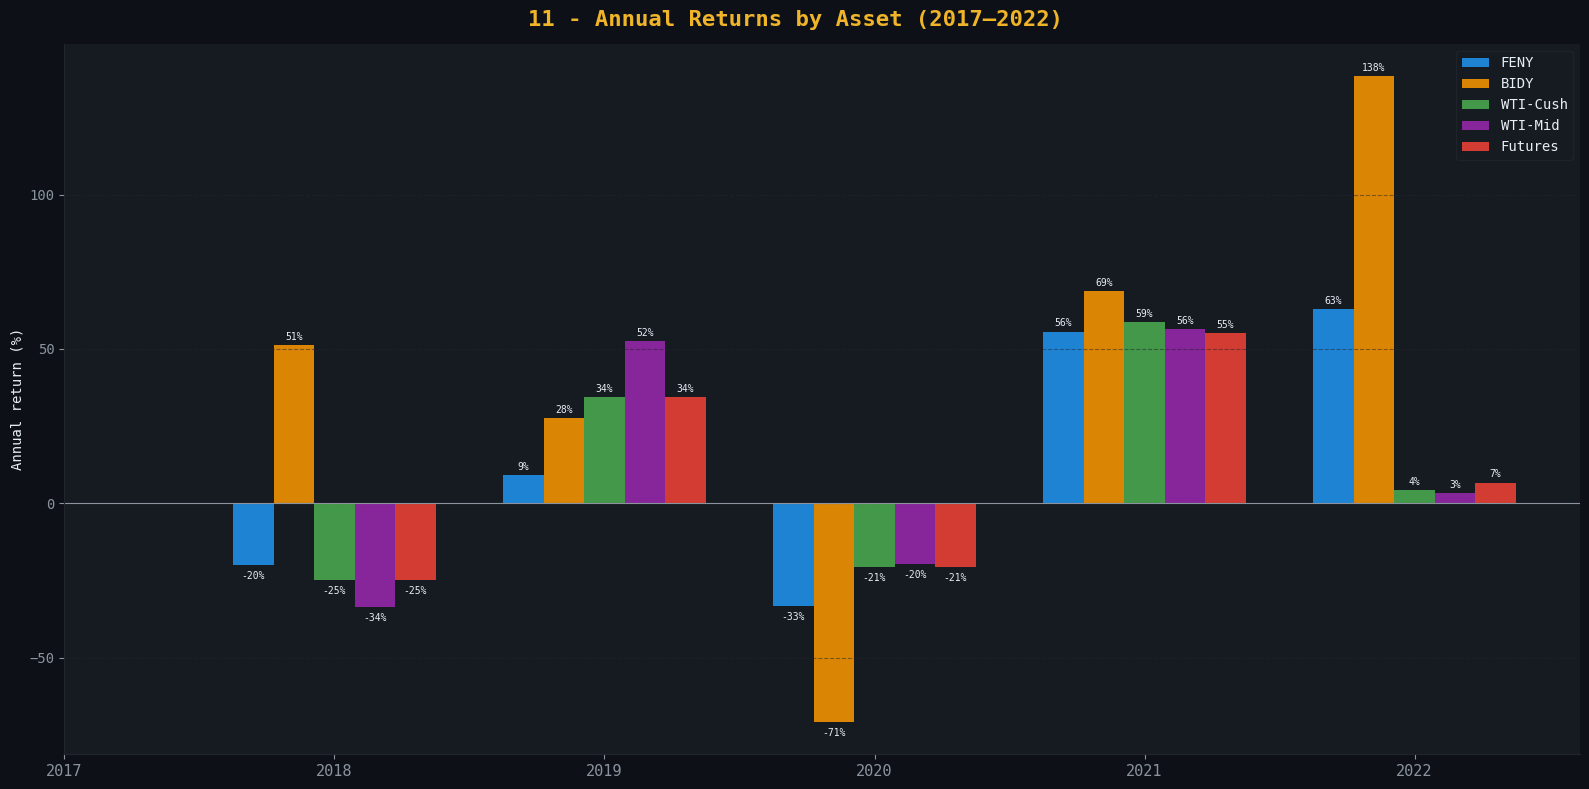

In [39]:
cols_ar  = ["feny", "bidy", "wti_cushing", "wti_midland", "fut_price"]
names_ar = ["FENY", "BIDY", "WTI-Cush", "WTI-Mid", "Futures"]
col_ar   = [C["feny"], C["bidy"], C["wti_c"], C["wti_m"], C["fut"]]

annual = {col: master[col].dropna().resample("YE").last().pct_change() * 100
          for col in cols_ar}
annual_df = pd.DataFrame(annual)
annual_df.index = annual_df.index.year
annual_df.columns = names_ar

fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle("11 - Annual Returns by Asset (2017–2022)", fontsize=16, color=C["accent"], fontweight="bold")

x = np.arange(len(annual_df))
n = len(names_ar)
w = 0.15
for i, (name, color) in enumerate(zip(names_ar, col_ar)):
    offset = (i - n / 2 + 0.5) * w
    vals   = annual_df[name].values
    bars   = ax.bar(x + offset, vals, width=w, color=color, alpha=0.85, label=name)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + (1 if v >= 0 else -2),
                    f"{v:.0f}%",
                    ha="center", va="bottom" if v >= 0 else "top",
                    fontsize=7, color=C["text"])

ax.set_xticks(x); ax.set_xticklabels(annual_df.index.astype(str), fontsize=11)
ax.axhline(0, color=C["muted"], lw=0.8)
ax.set_ylabel("Annual return (%)")
ax.legend(fontsize=10); ax.grid(True, axis="y")

fig.tight_layout()
save(fig, "11_annual_returns.png")
plt.show()

This graphs the 5 core sections' annual return. Notably, 2020 produced negative returns. 2018 was mostly negative as well due to the 2018 oil collapse in quarter 4.

## 18. FENY volume analysis

  saved -> outputs\12_volume_obv.png


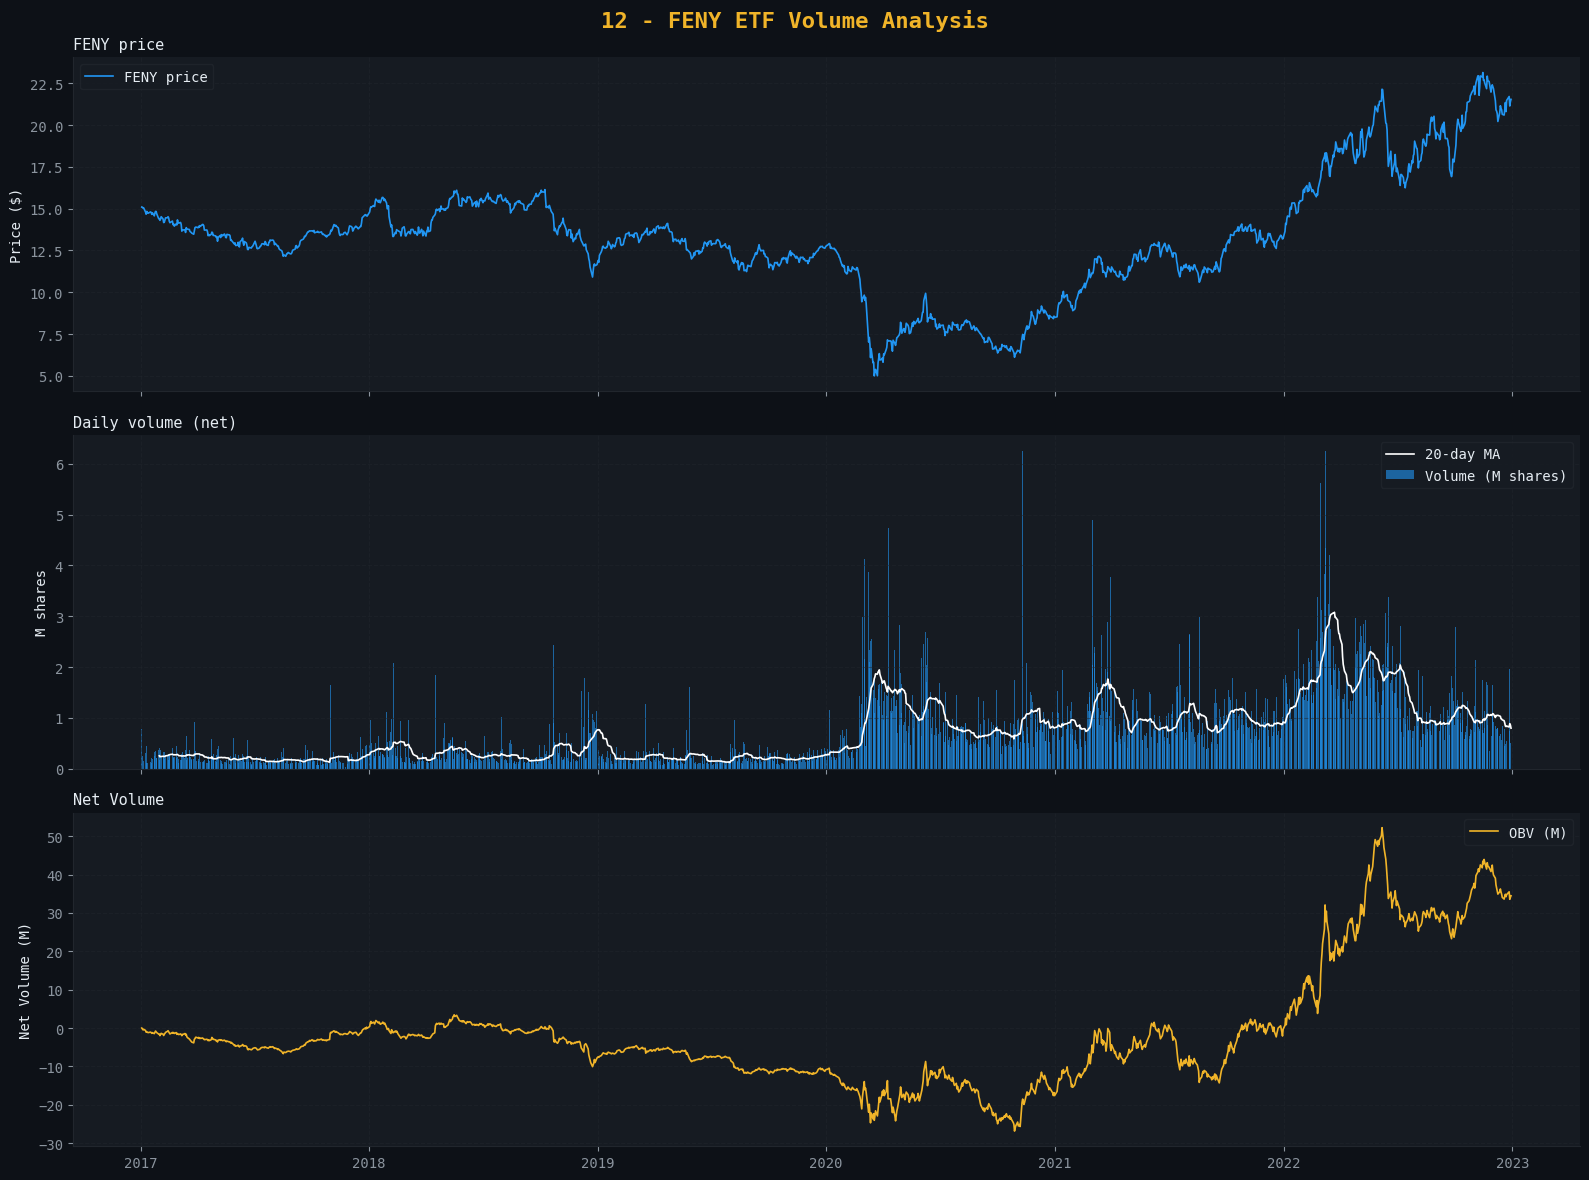

In [43]:
vol = master["Volume"].dropna()
price_f = master["feny"].dropna()
obv = (np.sign(price_f.diff()) * vol).fillna(0).cumsum()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle("12 - FENY ETF Volume Analysis",
             fontsize=16, color=C["accent"], fontweight="bold")

axes[0].plot(price_f.index, price_f, color=C["feny"], lw=1.2, label="FENY price")
axes[0].set_ylabel("Price ($)"); axes[0].legend(); axes[0].grid(True)
axes[0].set_title("FENY price", loc="left", fontsize=11)

axes[1].bar(vol.index, vol / 1e6, color=C["feny"], alpha=0.6, width=1.5, label="Volume (M shares)")
axes[1].plot(vol.index, vol.rolling(20).mean() / 1e6, color="white", lw=1.2, label="20-day MA")
axes[1].set_ylabel("M shares"); axes[1].legend(); axes[1].grid(True)
axes[1].set_title("Daily volume (net)", loc="left", fontsize=11)

axes[2].plot(obv.index, obv / 1e6, color=C["accent"], lw=1.2, label="OBV (M)")
axes[2].set_ylabel("Net Volume (M)"); axes[2].legend(); axes[2].grid(True)
axes[2].set_title("Net Volume", loc="left", fontsize=11)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save(fig, "12_volume_obv.png")
plt.show()

Similar to section 6 on futures and oil volume, we graph the FENY volume.
There is correlation between price, daily volume, and net volume. Whenever net volume and price diverge, there tends to be price reversals.

## 13. Summary statistics table

This shows the price endpoints, total return, annualized return/volatility, naive Sharpe (risk-free = 0), max drawdown, and higher moments (skewness, excess kurtosis).

  saved -> outputs\13_summary_table.png


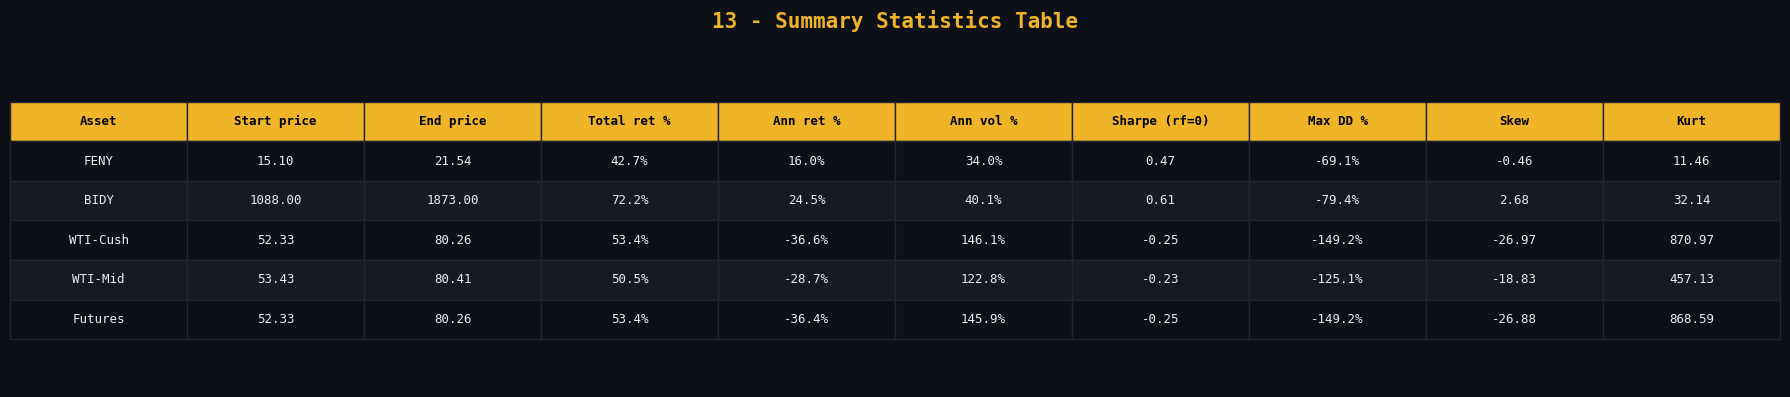

,Asset,Start price,End price,Total ret %,Ann ret %,Ann vol %,Sharpe (rf=0),Max DD %,Skew,Kurt
0,FENY,15.10,21.54,42.7%,16.0%,34.0%,0.47,-69.1%,-0.46,11.46
1,BIDY,1088.00,1873.00,72.2%,24.5%,40.1%,0.61,-79.4%,2.68,32.14
2,WTI-Cush,52.33,80.26,53.4%,-36.6%,146.1%,-0.25,-149.2%,-26.97,870.97
3,WTI-Mid,53.43,80.41,50.5%,-28.7%,122.8%,-0.23,-125.1%,-18.83,457.13
4,Futures,52.33,80.26,53.4%,-36.4%,145.9%,-0.25,-149.2%,-26.88,868.59


In [ ]:
summary_rows = []
for col, name in zip(cols_ar, names_ar):
    s  = master[col].dropna()
    r  = s.pct_change().dropna()
    dd = max_drawdown_series(s)
    summary_rows.append({
        "Asset": name,
        "Start price": f"{s.iloc[0]:.2f}",
        "End price": f"{s.iloc[-1]:.2f}",
        "Total ret %": f"{((s.iloc[-1]/s.iloc[0])-1)*100:.1f}%",
        "Ann ret %": f"{ret_ann[col]:.1f}%",
        "Ann vol %": f"{vol_ann[col]:.1f}%",
        "Sharpe (rf=0)": f"{ret_ann[col]/vol_ann[col]:.2f}",
        "Max DD %": f"{dd.min():.1f}%",
        "Skew": f"{stats.skew(r):.2f}",
        "Kurt": f"{stats.kurtosis(r):.2f}",
    })

summary_df = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(18, 4))
fig.suptitle("13 - Summary Statistics Table",
             fontsize=15, color=C["accent"], fontweight="bold")
ax.axis("off")
tbl = ax.table(cellText=summary_df.values,
               colLabels=summary_df.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.2)
for (r_i, _), cell in tbl.get_celld().items():
    cell.set_edgecolor(C["grid"])
    if r_i == 0:
        cell.set_facecolor(C["accent"])
        cell.set_text_props(color="black", fontweight="bold")
    else:
        cell.set_facecolor(C["panel"] if r_i % 2 == 0 else C["bg"])
        cell.set_text_props(color=C["text"])

fig.tight_layout()
save(fig, "13_summary_table.png")
plt.show()
summary_df

## 14. Normalized performance across all ten energy ETFs

  saved -> outputs\14_etf_normalised.png


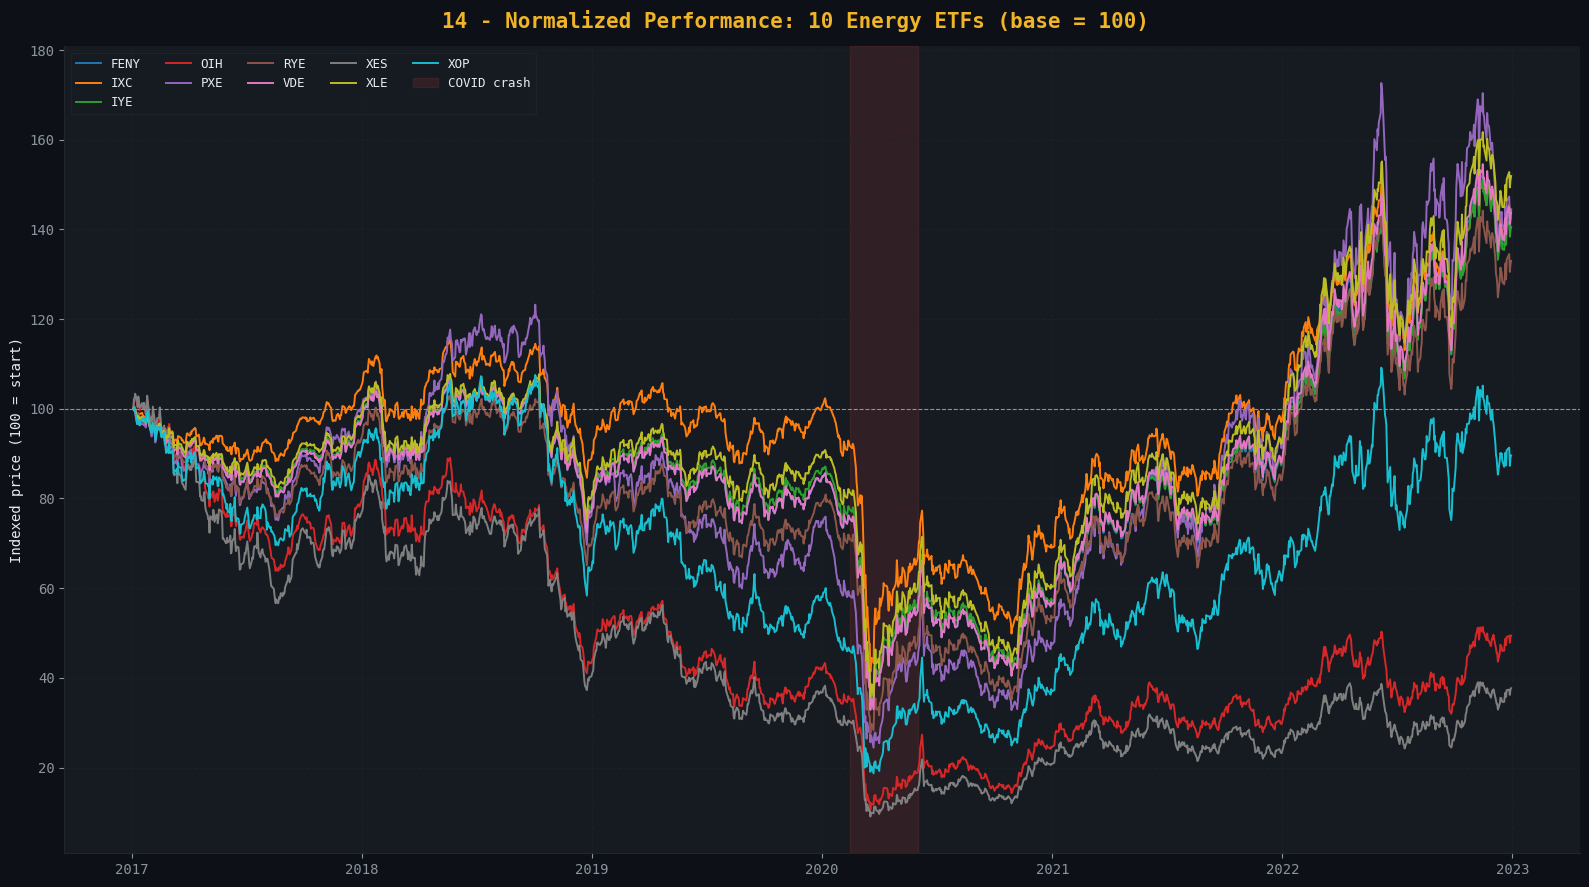

In [47]:
etf_indexed = etf_window / etf_window.iloc[0] * 100

fig, ax = plt.subplots(figsize=(16, 9))
fig.suptitle("14 - Normalized Performance: 10 Energy ETFs (base = 100)", fontsize=15, color=C["accent"], fontweight="bold")

for t in ETFS:
    ax.plot(etf_indexed.index, etf_indexed[t], lw=1.4, color=etf_colors[t], label=t)

ax.axhline(100, color=C["muted"], lw=0.8, ls="--")
ax.axvspan(pd.Timestamp("2020-02-15"), pd.Timestamp("2020-06-01"),
           alpha=0.12, color="#F44336", label="COVID crash")
ax.set_ylabel("Indexed price (100 = start)")
ax.legend(fontsize=9, ncol=5, loc="upper left")
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save(fig, "14_etf_normalised.png")
plt.show()

The graph shows a single line per ETF, all rebased to 100 at the first common date.
This shows how dispersion within the energy sector evolved. The COVID crash is shaded in red.

## 15. ETF correlation heatmap

Pearson correlation of daily simple returns across all ten ETFs. Strong internal correlation is expected within a single sector. The off-diagonal average is a useful gauge of how concentrated the sector is. This is similar to Section 4 earlier.

  saved -> outputs\15_etf_correlation.png


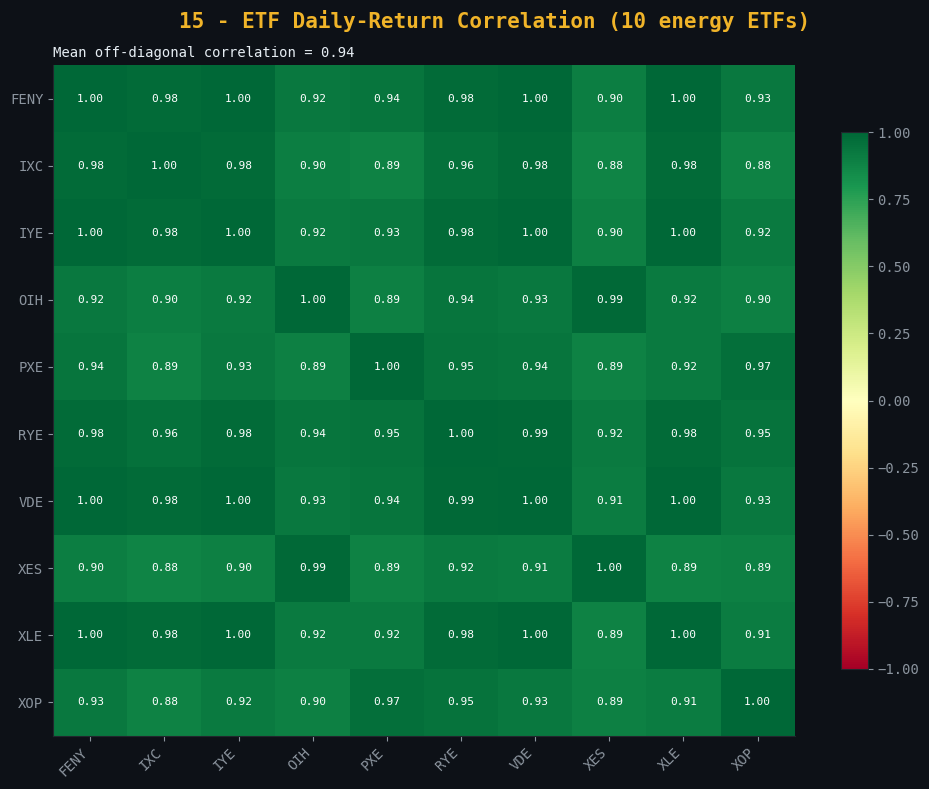

In [49]:
etf_rets = etf_window.pct_change().dropna(how="all")
etf_corr = etf_rets.corr()

# diagonal-masked off-diagonal mean
n = len(etf_corr)
off_diag_mean = (etf_corr.values.sum() - n) / (n * n - n)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("15 - ETF Daily-Return Correlation (10 energy ETFs)",
             fontsize=15, color=C["accent"], fontweight="bold")

im = ax.imshow(etf_corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(etf_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(etf_corr.index)
for i in range(n):
    for j in range(n):
        v = etf_corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="black" if abs(v) < 0.6 else "white")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Mean off-diagonal correlation = {off_diag_mean:.2f}",
             fontsize=10, loc="left")

fig.tight_layout()
save(fig, "15_etf_correlation.png")
plt.show()

## 16. ETF risk-return scatter and Sharpe ranking

Annualized return vs volatility for each ETF, with a horizontal Sharpe-ratio ranking. The top-Sharpe ETF in this period delivered the most return per unit of risk. The bottom is the most affected negatively by volatility.

  saved -> outputs\16_etf_risk_return.png


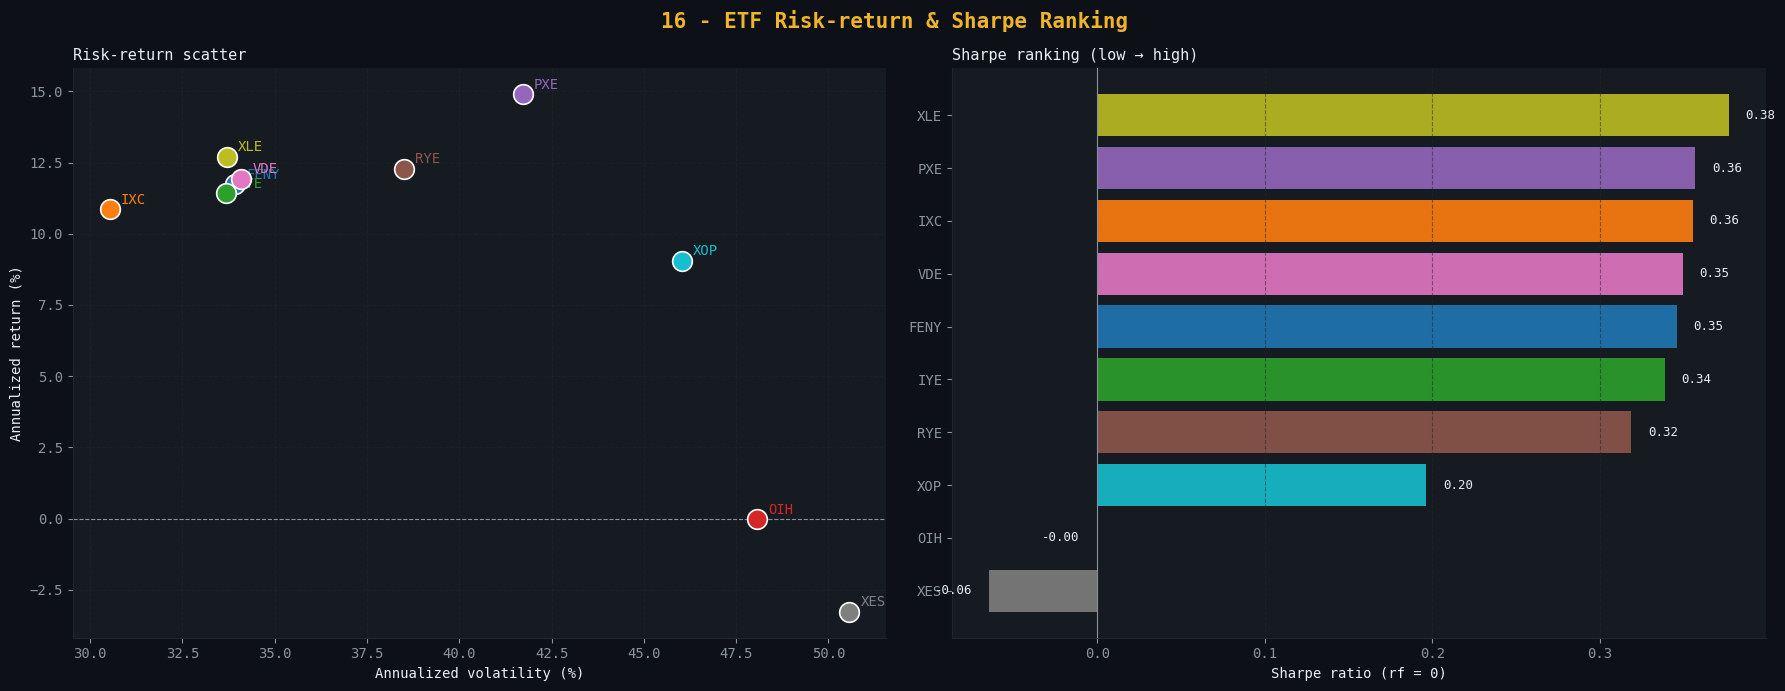

In [51]:
etf_ret = etf_rets.mean() * 252 * 100
etf_vol = etf_rets.std()  * np.sqrt(252) * 100
etf_sharpe = (etf_ret / etf_vol).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("16 - ETF Risk-return & Sharpe Ranking",
             fontsize=15, color=C["accent"], fontweight="bold")

ax = axes[0]
for t in ETFS:
    ax.scatter(etf_vol[t], etf_ret[t], s=200, color=etf_colors[t],
               edgecolors="white", lw=1.2, zorder=5)
    ax.annotate(t, (etf_vol[t], etf_ret[t]), textcoords="offset points",
                xytext=(8, 4), fontsize=10, color=etf_colors[t])
ax.axhline(0, color=C["muted"], lw=0.8, ls="--")
ax.set_xlabel("Annualized volatility (%)")
ax.set_ylabel("Annualized return (%)")
ax.set_title("Risk-return scatter", loc="left", fontsize=11)
ax.grid(True)

# Sharpe ranking
ax = axes[1]
bar_color = [etf_colors[t] for t in etf_sharpe.index]
ax.barh(etf_sharpe.index, etf_sharpe.values, color=bar_color, alpha=0.9)
ax.axvline(0, color=C["muted"], lw=0.8)
ax.set_xlabel("Sharpe ratio (rf = 0)")
ax.set_title("Sharpe ranking (low → high)", loc="left", fontsize=11)
ax.grid(True, axis="x")
for i, v in enumerate(etf_sharpe.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right",
            fontsize=9, color=C["text"])

fig.tight_layout()
save(fig, "16_etf_risk_return.png")
plt.show()